### LSE Data Analytics Online Career Accelerator

# Course 2: Data Analytics using Python

## Assignment: Diagnostic Analysis using Python

You’ll be working with real-world data to address a problem faced by the National Health Service (NHS). The analysis will require you to utilise Python to explore the available data, create visualisations to identify trends, and extract meaningful insights to inform decision-making. 

### A note for students using this template
This Jupyter Notebook is a template you can use to complete the Course 2 assignment: Diagnostic Analysis using Python. 

Keep in mind: 
- You are **not required** to use this template to complete the assignment. 
- If you decide to use this template for your assignment, make a copy of the notebook and save it using the assignment naming convention: **LastName_FirstName_DA201_Assignment_Notebook.ipynb**.
- The workflow suggested in this template follows the Assignment Activities throughout the course.
- Refer to the guidance on the Assignment Activity pages for specific details. 
- The markup and comments in this template identify the key elements you need to complete before submitting the assignment.
- Make this notebook your own by adding your process notes and rationale using markdown, add links, screenshots, or images to support your analysis, refine or clarify the comments, and change the workflow to suit your process.
- All elements should be functional and visible in your Notebook. 
- After completing each Assignment Activity, back up your work to a safe location. This would allow you to revert to a previous state in the case of making a mistake in the code, or deleting a section by mistake. (A simple way of doing this is to save or mail a compressed version at frequent intervals).

 > ***Markdown*** Remember to change cell types to `Markdown`. You can review [Markdown basics](https://docs.github.com/en/get-started/writing-on-github/getting-started-with-writing-and-formatting-on-github/basic-writing-and-formatting-syntax) to find out how to add formatted text, links, and images to your notebook.

# 

# Assignment activity 1

### Plan your approach

**Approach:**
- Import and explore the data provided in the three CSV files.
- Familiarise myself with the variables present in each dataset to answer the questions effectively.
- Identify seasonal trends, daily trends and monthly trends to uncover valuable patterns and insights.
- Carry out sentiment analysis using the Twitter data to understand public sentiment and trends.
- Analyse the resource utilisation using the 1.2 million appointments per day benchmark figure to understand if the current staffing capacity is sufficient.

# Assignment activity 2

### Prepare your workstation

In [62]:
# Import the necessary libraries.
import pandas as pd
import numpy as np

# Optional - Ignore warnings.
import warnings
warnings.filterwarnings('ignore')

In [63]:
# Import and sense-check the 'actual_duration.csv' file.
ad = pd.read_csv('actual_duration.csv')
# View the DataFrame.
ad

,sub_icb_location_code,sub_icb_location_ons_code,sub_icb_location_name,icb_ons_code,region_ons_code,appointment_date,actual_duration,count_of_appointments
0,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,31-60 Minutes,364
1,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,21-30 Minutes,619
2,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,6-10 Minutes,1698
3,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,Unknown / Data Quality,1277
4,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,16-20 Minutes,730
...,...,...,...,...,...,...,...,...
137788,X2C4Y,E38000254,NHS West Yorkshire ICB - X2C4Y,E54000054,E40000012,30-Jun-22,31-60 Minutes,430
137789,X2C4Y,E38000254,NHS West Yorkshire ICB - X2C4Y,E54000054,E40000012,30-Jun-22,21-30 Minutes,751
137790,X2C4Y,E38000254,NHS West Yorkshire ICB - X2C4Y,E54000054,E40000012,30-Jun-22,16-20 Minutes,921
137791,X2C4Y,E38000254,NHS West Yorkshire ICB - X2C4Y,E54000054,E40000012,30-Jun-22,11-15 Minutes,1439


In [64]:
# Determine whether there are missing values.
ad_missing = ad[ad.isna().values.any(axis = 1)]

# View ad_missing
ad_missing

,sub_icb_location_code,sub_icb_location_ons_code,sub_icb_location_name,icb_ons_code,region_ons_code,appointment_date,actual_duration,count_of_appointments


In [65]:
# Check for duplicate records.
# There are no duplicate records in actual_duration.
duplicates_ad = ad[ad.duplicated()].sum()
duplicates_ad

sub_icb_location_code        0
sub_icb_location_ons_code    0
sub_icb_location_name        0
icb_ons_code                 0
region_ons_code              0
appointment_date             0
actual_duration              0
count_of_appointments        0
dtype: object

In [66]:
# Determine the metadata of the data set.
ad.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137793 entries, 0 to 137792
Data columns (total 8 columns):
 #   Column                     Non-Null Count   Dtype 
---  ------                     --------------   ----- 
 0   sub_icb_location_code      137793 non-null  object
 1   sub_icb_location_ons_code  137793 non-null  object
 2   sub_icb_location_name      137793 non-null  object
 3   icb_ons_code               137793 non-null  object
 4   region_ons_code            137793 non-null  object
 5   appointment_date           137793 non-null  object
 6   actual_duration            137793 non-null  object
 7   count_of_appointments      137793 non-null  int64 
dtypes: int64(1), object(7)
memory usage: 8.4+ MB


In [67]:
# Determine the descriptive statistics of the data set.
ad.describe()

,count_of_appointments
count,137793.000000
mean,1219.080011
std,1546.902956
min,1.000000
25%,194.000000
50%,696.000000
75%,1621.000000
max,15400.000000


In [68]:
# Import and sense-check the appointments_regional.csv data set as ar.
ar = pd.read_csv('appointments_regional.csv')

# View the DataFrame.
ar

,icb_ons_code,appointment_month,appointment_status,hcp_type,appointment_mode,time_between_book_and_appointment,count_of_appointments
0,E54000034,2020-01,Attended,GP,Face-to-Face,1 Day,8107
1,E54000034,2020-01,Attended,GP,Face-to-Face,15 to 21 Days,6791
2,E54000034,2020-01,Attended,GP,Face-to-Face,2 to 7 Days,20686
3,E54000034,2020-01,Attended,GP,Face-to-Face,22 to 28 Days,4268
4,E54000034,2020-01,Attended,GP,Face-to-Face,8 to 14 Days,11971
...,...,...,...,...,...,...,...
596816,E54000050,2022-06,Unknown,Unknown,Unknown,2 to 7 Days,21
596817,E54000050,2022-06,Unknown,Unknown,Unknown,22 to 28 Days,8
596818,E54000050,2022-06,Unknown,Unknown,Unknown,8 to 14 Days,28
596819,E54000050,2022-06,Unknown,Unknown,Unknown,More than 28 Days,17


**No** missing values were found in ar.

In [69]:
# Determine whether there are missing values.
ar_missing = ar[ar.isna().values.any(axis = 1)]

# View ar_missing
ar_missing

,icb_ons_code,appointment_month,appointment_status,hcp_type,appointment_mode,time_between_book_and_appointment,count_of_appointments


**21604** duplicates were found in the 'appointments_regional.csv' file.

In [70]:
# Check for duplicate records in appointments_regional.
duplicates_ar = ar[ar.duplicated()].sum()
value_counts = ar.duplicated(keep=False).value_counts()
print("Breakdown of unique vs duplicate rows:")
print(value_counts)

# Remove 21604 duplicates from appointments_regional and keep the unique rows.
ar_unique = ar.drop_duplicates()
print(f"Original DataFrame shape: {ar.shape}")
print(f"DataFrame after removing duplicates: {ar_unique.shape}")


Breakdown of unique vs duplicate rows:
False    556686
True      40135
Name: count, dtype: int64
Original DataFrame shape: (596821, 7)
DataFrame after removing duplicates: (575217, 7)


In [71]:
# Determine the metadata of the data set.
ar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 596821 entries, 0 to 596820
Data columns (total 7 columns):
 #   Column                             Non-Null Count   Dtype 
---  ------                             --------------   ----- 
 0   icb_ons_code                       596821 non-null  object
 1   appointment_month                  596821 non-null  object
 2   appointment_status                 596821 non-null  object
 3   hcp_type                           596821 non-null  object
 4   appointment_mode                   596821 non-null  object
 5   time_between_book_and_appointment  596821 non-null  object
 6   count_of_appointments              596821 non-null  int64 
dtypes: int64(1), object(6)
memory usage: 31.9+ MB


In [72]:
# Determine the descriptive statistics of the data set.
ar.describe()

,count_of_appointments
count,596821.000000
mean,1244.601857
std,5856.887042
min,1.000000
25%,7.000000
50%,47.000000
75%,308.000000
max,211265.000000


In [73]:
# Import and sense-check the national_categories.xlsx data set as nc.
nc = pd.read_csv('national_categories.csv')

# View the DataFrame.
nc

,appointment_date,icb_ons_code,sub_icb_location_name,service_setting,context_type,national_category,count_of_appointments,appointment_month
0,02/08/2021,E54000050,NHS North East and North Cumbria ICB - 00L,Primary Care Network,Care Related Encounter,Patient contact during Care Home Round,3,2021-08
1,02/08/2021,E54000050,NHS North East and North Cumbria ICB - 00L,Other,Care Related Encounter,Planned Clinics,7,2021-08
2,02/08/2021,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Home Visit,79,2021-08
3,02/08/2021,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,General Consultation Acute,725,2021-08
4,02/08/2021,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Structured Medication Review,2,2021-08
...,...,...,...,...,...,...,...,...
817389,30/06/2022,E54000054,NHS West Yorkshire ICB - X2C4Y,Extended Access Provision,Care Related Encounter,Unplanned Clinical Activity,12,2022-06
817390,30/06/2022,E54000054,NHS West Yorkshire ICB - X2C4Y,Extended Access Provision,Care Related Encounter,Planned Clinics,4,2022-06
817391,30/06/2022,E54000054,NHS West Yorkshire ICB - X2C4Y,Extended Access Provision,Care Related Encounter,Planned Clinical Procedure,92,2022-06
817392,30/06/2022,E54000054,NHS West Yorkshire ICB - X2C4Y,Extended Access Provision,Care Related Encounter,General Consultation Routine,4,2022-06


**No** missing values were found in nc.

In [74]:
# Determine whether there are missing values.
nc_missing = nc[nc.isna().values.any(axis = 1)]

# View nc_missing
nc_missing

,appointment_date,icb_ons_code,sub_icb_location_name,service_setting,context_type,national_category,count_of_appointments,appointment_month


In [75]:
# Determine the metadata of the data set.
nc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 817394 entries, 0 to 817393
Data columns (total 8 columns):
 #   Column                 Non-Null Count   Dtype 
---  ------                 --------------   ----- 
 0   appointment_date       817394 non-null  object
 1   icb_ons_code           817394 non-null  object
 2   sub_icb_location_name  817394 non-null  object
 3   service_setting        817394 non-null  object
 4   context_type           817394 non-null  object
 5   national_category      817394 non-null  object
 6   count_of_appointments  817394 non-null  int64 
 7   appointment_month      817394 non-null  object
dtypes: int64(1), object(7)
memory usage: 49.9+ MB


In [76]:
# Determine the descriptive statistics of the data set.
nc.describe()

,count_of_appointments
count,817394.000000
mean,362.183684
std,1084.576600
min,1.000000
25%,7.000000
50%,25.000000
75%,128.000000
max,16590.000000


### Explore the data set

**Question 1:** How many locations are there in the data set?

**Answer:** NHS England is divided into 7 regions, 42 ICBs (Integrated Care Boards) and 106 sub-ICB locations.

In [77]:
# Determine the total number of locations.
num_regions = ad['region_ons_code'].nunique()
num_icb_loc = nc['icb_ons_code'].nunique()
num_sub_icb_loc = nc['sub_icb_location_name'].nunique()

# View the total number of locations.
print(f"Number of regions: {num_regions}")
print(f"Number of ICB locations: {num_icb_loc}")
print(f"Number of sub_ICB locations: {num_sub_icb_loc}")

Number of regions: 7
Number of ICB locations: 42
Number of sub_ICB locations: 106


**Question 2:** What are the five locations with the highest number of appointments?



**Answer:** 
1. The top 5 places with the highest number of appointments are ***NHS North West London ICB - W2U3Z***, ***NHS Kent and Medway ICB - 91Q***, ***NHS Devon ICB - 15N***, ***NHS Hampshire and Isle Of Wight ICB - D9Y0V*** and ***NHS North East London ICB - A3A8R.***
2. The 'appointments_regional.csv' file had the highest number of appointments **(742529759)**

In [78]:
# Determine the top five locations based on record count.
top_five = nc['sub_icb_location_name'].value_counts().head(5)

# View Top 5 locations. 
top_five


sub_icb_location_name
NHS North West London ICB - W2U3Z              13007
NHS Kent and Medway ICB - 91Q                  12637
NHS Devon ICB - 15N                            12526
NHS Hampshire and Isle Of Wight ICB - D9Y0V    12171
NHS North East London ICB - A3A8R              11837
Name: count, dtype: int64

In [79]:
# Top 5 locations based on number of appointments
nc_top_locs = nc.groupby('sub_icb_location_name')[['count_of_appointments']]\
        .sum().sort_values('count_of_appointments', ascending=False).head(5).reset_index()\
        .rename(columns={'sub_icb_location_name':'Sub ICB Location',\
                         'count_of_appointments':'Total Appointments'})

nc_top_locs

,Sub ICB Location,Total Appointments
0,NHS North West London ICB - W2U3Z,12142390
1,NHS North East London ICB - A3A8R,9588891
2,NHS Kent and Medway ICB - 91Q,9286167
3,NHS Hampshire and Isle Of Wight ICB - D9Y0V,8288102
4,NHS South East London ICB - 72Q,7850170


In [80]:
# This returns total appointments by sub_ICB_location and sorts them in descending order from nc.
# This code also renames the columns and returns the top five records.
nc_top_locs = nc.groupby('sub_icb_location_name')[['count_of_appointments']]\
        .sum().sort_values('count_of_appointments', ascending=False).head(5)\
        .reset_index()\
        .rename(columns={'sub_icb_location_name':'Sub ICB Location',\
                         'count_of_appointments':'Total Appointments in nc'})

# Calculate and print the sum of appointments in nc.
total_nc = nc['count_of_appointments'].sum()
print("Total appointments in nc:",total_nc)

# Add '% of Total' column and view the top 5 in a table.
nc_top_locs['% of Total'] = nc_top_locs['Total Appointments in nc']/total_nc * 100
nc_top_locs.round(1)


Total appointments in nc: 296046770


,Sub ICB Location,Total Appointments in nc,% of Total
0,NHS North West London ICB - W2U3Z,12142390,4.1
1,NHS North East London ICB - A3A8R,9588891,3.2
2,NHS Kent and Medway ICB - 91Q,9286167,3.1
3,NHS Hampshire and Isle Of Wight ICB - D9Y0V,8288102,2.8
4,NHS South East London ICB - 72Q,7850170,2.7


In [81]:
# This returns total appointments by sub_ICB_location and sorts them in descending order from nc.
# This code also renames the columns and returns the top five records.
ad_top_locs = ad.groupby('sub_icb_location_name')[['count_of_appointments']]\
        .sum().sort_values('count_of_appointments', ascending=False).head(5)\
        .reset_index()\
        .rename(columns={'sub_icb_location_name':'Sub ICB Location',\
                         'count_of_appointments':'Total Appointments in ad'})

# Calculate and print the sum of appointments in ad.
total_ad = ad['count_of_appointments'].sum()
print("Total appointments in ad:",total_ad)

# Add '% of Total' column and view the top 5 in a table.
ad_top_locs['% of Total'] = ad_top_locs['Total Appointments in ad']/total_ad * 100
ad_top_locs.round(1)


Total appointments in ad: 167980692


,Sub ICB Location,Total Appointments in ad,% of Total
0,NHS North West London ICB - W2U3Z,6976986,4.2
1,NHS North East London ICB - A3A8R,5341883,3.2
2,NHS Kent and Medway ICB - 91Q,5209641,3.1
3,NHS Hampshire and Isle Of Wight ICB - D9Y0V,4712737,2.8
4,NHS South East London ICB - 72Q,4360079,2.6


In [82]:
# This returns total appointments by ICB location and sorts them in descending order from ar.
# This code also renames the columns and adds an additional column to show the % of the total
# appointments across all 42 ICB locations.

ar_top_locs = ar_unique.groupby('icb_ons_code')[['count_of_appointments']]\
        .sum().sort_values('count_of_appointments', ascending=False).head()\
        .reset_index()\
        .rename(columns={'icb_ons_code':'ICB ONS Code',\
                         'count_of_appointments':'Total Appointments in ar'})

total_ar = ar_unique['count_of_appointments'].sum()
print("Total appointments in ar:",total_ar)

ar_top_locs['% of Total'] = ar_top_locs['Total Appointments in ar']/total_ar * 100
ar_top_locs.round(1)

Total appointments in ar: 742529759


,ICB ONS Code,Total Appointments in ar,% of Total
0,E54000050,43054121,5.8
1,E54000054,36075020,4.9
2,E54000057,34003953,4.6
3,E54000008,33064205,4.5
4,E54000027,29380767,4.0


**Question 3:** How many service settings, context types, national categories, and appointment statuses are there?

**Observations:**
1. There are 5 service settings
2. There are a total of 359274 GP settings
3. General Practice had 91.5% of the appointments
4. There are 3 context types
5. Related Encounters have the highest number of appointments (86.8%)
6. There are 18 National Categories
7. The General Consultation Routine appointment type made 32.9% of the total appointments 

In [83]:
# Determine the number of service settings.
service = nc['service_setting'].nunique()
print(f"Categories of Service Settings: {service}")

Categories of Service Settings: 5


In [84]:
# Determine the number of service settings.
# This returns total appointments by setting and sorts them in descending order.
# This code also renames the columns and adds an additional column to show the % of the total
# appointments across all five service settings.

settings = nc.groupby('service_setting')[['count_of_appointments']]\
        .sum().sort_values('count_of_appointments', ascending=False)\
        .reset_index()\
        .rename(columns={'service_setting':'Service Setting',\
                         'count_of_appointments':'Total Appointments'})
# Sum of the Total number of Appointments.
total_nc = settings['Total Appointments'].sum() 
print("Total appointments in nc:",total_nc)

#Add % of total appointments.
settings['% of Total'] = settings['Total Appointments']/total_nc * 100

# Count the number of records (rows) for each service setting.
num_service= nc['service_setting'].value_counts().reset_index()
num_service.columns = ['Service Setting', 'Count of Service Setting']

# Merging DataFrames.
merged_df = settings.merge(num_service, on='Service Setting', how='left')

# Reordering columns in the merged DataFrame.
merged_df = merged_df[['Service Setting', 'Count of Service Setting', 'Total Appointments', '% of Total']]

# Round values and display as a table.
merged_df.round(1).head()

Total appointments in nc: 296046770


,Service Setting,Count of Service Setting,Total Appointments,% of Total
0,General Practice,359274,270811691,91.5
1,Unmapped,27419,11080810,3.7
2,Primary Care Network,183790,6557386,2.2
3,Other,138789,5420076,1.8
4,Extended Access Provision,108122,2176807,0.7


In [85]:
# Determine the number of context types.
num_ct = nc['context_type'].nunique()
print(f"Categories of Context Types: {num_ct}")

Categories of Context Types: 3


In [86]:
# Determine the number of context types.
# This returns total appointments by context type and sorts them in descending order.
# This code also renames the columns and adds an additional column to show the % of the total
# appointments across all three context types.

context = nc.groupby('context_type')[['count_of_appointments']]\
        .sum().sort_values('count_of_appointments', ascending=False)\
        .reset_index()\
        .rename(columns={'context_type':'Context Type',\
                         'count_of_appointments':'Total Appointments'})

print("Total appointments in nc:",total_nc)

context['% of Total'] = context['Total Appointments']/total_nc * 100
context.round(1)

Total appointments in nc: 296046770


,Context Type,Total Appointments,% of Total
0,Care Related Encounter,257075158,86.8
1,Inconsistent Mapping,27890802,9.4
2,Unmapped,11080810,3.7


In [87]:
# Determine the number of national categories.
number_nc = nc['national_category'].value_counts()
print(f" Number of National Categories: {number_nc.size}")

 Number of National Categories: 18


In [88]:
# Determine the number of national categories.
num_national_category = nc['national_category'].value_counts()\
                        .reset_index().rename(columns={'national_category': 'National Category',
                                                      'count': 'Count of National Category'})

#View the number of national categories.
num_national_category

# View DataFrame.
num_national_category


,National Category,Count of National Category
0,Inconsistent Mapping,89494
1,General Consultation Routine,89329
2,General Consultation Acute,84874
3,Planned Clinics,76429
4,Clinical Triage,74539
5,Planned Clinical Procedure,59631
6,Structured Medication Review,44467
7,Service provided by organisation external to t...,43095
8,Home Visit,41850
9,Unplanned Clinical Activity,40415


In [89]:
# Determine the number of national categories.
# This returns total appointments by national category and sorts them in descending order.
# This code also renames the columns and adds an additional column to show the % of the total
# appointments across all 18 national categories.

category = nc.groupby('national_category')[['count_of_appointments']]\
        .sum().sort_values('count_of_appointments', ascending=False)\
        .reset_index()\
        .rename(columns={'national_category':'National Category',\
                         'count_of_appointments':'Total Appointments'})

# Sum of the Total number of Appointments.
total_nc = nc['count_of_appointments'].sum()
print("Total appointments in nc:",total_nc)

#Add % of total appointments.
category['% of Total'] = category['Total Appointments']/total_nc * 100

# Count the number of records(rows) for each national category.
num_nc = nc['national_category'].value_counts().reset_index()
num_nc.columns = [ 'National Category', 'Count of Category']

# Merging DataFrames.
merged_nc = category.merge(num_nc, on = 'National Category', how ='left')

# Reordering columns in merged DataFrame.
merged_nc = merged_nc[['National Category', 'Count of Category', 'Total Appointments', '% of Total']]

# Round values and display as a table.
merged_nc.round(1).head()

Total appointments in nc: 296046770


,National Category,Count of Category,Total Appointments,% of Total
0,General Consultation Routine,89329,97271522,32.9
1,General Consultation Acute,84874,53691150,18.1
2,Clinical Triage,74539,41546964,14.0
3,Planned Clinics,76429,28019748,9.5
4,Inconsistent Mapping,89494,27890802,9.4


In [90]:
# Determine the number of categories of appointment statuses.
num_as = ar['appointment_status'].nunique()
print(f"Categories of Appointment Statuses: {num_as}")

Categories of Appointment Statuses: 3


In [91]:
# Determine the number of appointment statuses.
# This returns total appointments by appointment status and sorts them in descending order.
# This code also renames the columns and adds an additional column to show the % of the total.
# appointments across three appointment statuses.

status = ar_unique.groupby('appointment_status')[['count_of_appointments']]\
        .sum().sort_values('count_of_appointments', ascending=False)\
        .reset_index()\
        .rename(columns={'appointment_status':'Appointment Status',\
                         'count_of_appointments':'Total Appointments'})

# Sum of the Total number of Appointments.
total_ar = ar_unique['count_of_appointments'].sum()
print("Total appointments in ar:",total_ar)

status['% of Total'] = status['Total Appointments']/total_ar * 100
status.round(1)

Total appointments in ar: 742529759


,Appointment Status,Total Appointments,% of Total
0,Attended,677646088,91.3
1,Unknown,34050656,4.6
2,DNA,30833015,4.2


**Question 4:** What percentage of the appointments were missed?

**Answer: 4.2% of the appointments were missed.**

In [92]:
# Determine the percentage of missed appointments in ar_unique.
# Not considering status type 'Unknown' due to insufficient context for the status type.

# Calculate totals for each appointment status type.
status_total = ar_unique.groupby('appointment_status')['count_of_appointments'].sum()
total_appointments = status_total.sum()

# Determine the number of missed (DNA) and attended appointments.
missed = status_total.get('DNA', 0)
attended = status_total.get('Attended', 0)

# Calculate Percentages.
percent_missed = (missed / total_appointments) * 100
percent_attended = (attended / total_appointments) * 100

# View result.
print(f"Percent of Missed Appointments: {percent_missed.round(1)}%")
print(f"Percent of Appointments Attended: {percent_attended.round(1)}%")



Percent of Missed Appointments: 4.2%
Percent of Appointments Attended: 91.3%


**Question 5:** Which location had the highest number of missed appointments?

**Answer: NHS Greater Manchester ICB - 01G (E54000057) had the highest number of missed appointments (0.3%).**

In [93]:
# Filter data for missed appointments ('DNA').
missed_ar = ar_unique[ar_unique['appointment_status'] == 'DNA']

# Group by icb_ons_code and sum the missed appointments.
loc_ar = missed_ar.groupby('icb_ons_code')['count_of_appointments'].sum().reset_index()

# Find the location with the maximum missed appointments.
max_missed = loc_ar.loc[loc_ar['count_of_appointments'].idxmax()]

# View Result.
print(f"Location with the highest number of missed appointments is {max_missed['icb_ons_code']} with {max_missed['count_of_appointments']} missed appointments.")

# Sort and show the top N locations.
top_locations = missed_ar.groupby('icb_ons_code')['count_of_appointments'].sum().reset_index()\
                .sort_values('count_of_appointments',ascending=False).head(5)

# Calculate the percentage of total appointments.
total_ar = ar_unique['count_of_appointments'].sum()

top_locations['% of Total'] = (top_locations['count_of_appointments'] / total_ar * 100).round(1)

print(f"The top 5 locations based on number of missed appointments:")
top_locations

Location with the highest number of missed appointments is E54000057 with 1928168 missed appointments.
The top 5 locations based on number of missed appointments:


,icb_ons_code,count_of_appointments,% of Total
36,E54000057,1928168,0.3
29,E54000050,1668009,0.2
0,E54000008,1648264,0.2
14,E54000029,1317005,0.2
12,E54000027,1286262,0.2


# Summary:
The DataFrames were imported and checked for duplicates and missing values. The DataFrames were then sense-checked to ensure accurate and consistent data. 
With the exploration of the data, it was found that the appointment_regionals DataFrame had the highest volume of data spanning from January 2020 to June 2022. This made the dataset the most apt one to perform data analysis and uncover valuable insights. 

# Assignment activity 3 

### Continue to explore the data and search for answers to more specific questions posed by the NHS.

### Extra questions were added to explore the data further to gather valuable insights 

**Question 1:** How many appointment modes are there?

In [94]:
# Determine the various modes of appointments.
# Determine the most popular appointment mode.

mode = ar_unique.groupby('appointment_mode')[['count_of_appointments']]\
       .sum().sort_values('count_of_appointments', ascending = False)\
       .reset_index()\
       .rename(columns={'appointment_mode': 'Appointment Mode',\
                        'count_of_appointments': 'Total Appointments'})

# Sum of the Total number of Appointments.
total_ar = ar_unique['count_of_appointments'].sum()
print("Total appointments in ar:",total_ar)


mode['% of Total'] = mode['Total Appointments']/total_ar * 100
mode.round(1)

Total appointments in ar: 742529759


,Appointment Mode,Total Appointments,% of Total
0,Face-to-Face,439876928,59.2
1,Telephone,267752505,36.1
2,Unknown,26439308,3.6
3,Home Visit,4848743,0.7
4,Video/Online,3612275,0.5


**Question 2:** How many HCP types are there?

In [95]:
# Determine the different types of healthcare professionals.
# This returns total appointments per HCP type and sorts them in descending order.
# This code also renames the columns and adds an additional column to show the % of the total.

hcp = ar_unique.groupby('hcp_type')[['count_of_appointments']]\
     .sum().sort_values('count_of_appointments', ascending = False)\
     .reset_index()\
     .rename(columns = {'hcp_type':'Type of Healthcare Professional',\
                        'count_of_appointments':'Total Appointments'})

# Sum of all Appointments.
total_ar = ar_unique['count_of_appointments'].sum()
print("Total appointments in ar:",total_ar)

hcp['% of Total'] = hcp['Total Appointments']/total_ar * 100
hcp.round(1)


Total appointments in ar: 742529759


,Type of Healthcare Professional,Total Appointments,% of Total
0,GP,379532056,51.1
1,Other Practice staff,339528981,45.7
2,Unknown,23468722,3.2


**Question 3:** How were the times between the bookings and appointments measured?

In [96]:
# Determine the times between bookings and appointments.
# This returns total appointments by time between booking and appointment and sorts them in descending order.
# This code also renames the columns and adds an additional column to show the % of the total
# Appointments segregated into 8 time intervals are displayed.

booking_time = ar_unique.groupby('time_between_book_and_appointment')[['count_of_appointments']]\
        .sum().sort_values('count_of_appointments', ascending=False)\
        .reset_index()\
        .rename(columns={'time_between_book_and_appointment':'Time between booking and appointment',\
                         'count_of_appointments':'Total Appointments'})

# Sum of all Appointments.
total_ar = ar_unique['count_of_appointments'].sum()
print("Total appointments in ar:",total_ar)

booking_time['% of Total'] = booking_time['Total Appointments']/total_ar * 100
booking_time.round(1)

Total appointments in ar: 742529759


,Time between booking and appointment,Total Appointments,% of Total
0,Same Day,342701908,46.2
1,2 to 7 Days,153749341,20.7
2,8 to 14 Days,86806958,11.7
3,1 Day,67673007,9.1
4,15 to 21 Days,42673981,5.7
5,22 to 28 Days,25503575,3.4
6,More than 28 Days,23024683,3.1
7,Unknown / Data Quality,396306,0.1


**Question 5:** How long do appointments last?

In [97]:
# Determine how long appointments last.
# This returns total appointments by appointment duration and sorts them in descending order.
# This code also renames the columns and adds an additional column to show the % of the total.
# Appointments across 7 durations.

duration = ad.groupby('actual_duration')[['count_of_appointments']]\
        .sum().sort_values('count_of_appointments', ascending=False)\
        .reset_index()\
        .rename(columns={'actual_duration':'Actual Duration',\
                         'count_of_appointments':'Total Appointments'})

print("Total appointments in ad:",total_ad)

duration['% of Total'] = duration['Total Appointments']/total_ad * 100
duration.round(1)

Total appointments in ad: 167980692


,Actual Duration,Total Appointments,% of Total
0,Unknown / Data Quality,40284086,24.0
1,6-10 Minutes,33800815,20.1
2,1-5 Minutes,28600865,17.0
3,11-15 Minutes,25160882,15.0
4,16-20 Minutes,16004247,9.5
5,21-30 Minutes,15026365,8.9
6,31-60 Minutes,9103432,5.4


**Question 5:** Between what dates were appointments scheduled? 

In [98]:
# Change the date format of ad['appointment_date'] from object to datetime format.
# Using errors = coerce for rows that might have bad formats. 
from datetime import datetime
ad['appointment_date'] = pd.to_datetime(ad['appointment_date'], format='%d-%b-%y', errors = 'coerce')

# View the DateFrame.
ad['appointment_date'].head()

0   2021-12-01
1   2021-12-01
2   2021-12-01
3   2021-12-01
4   2021-12-01
Name: appointment_date, dtype: datetime64[ns]

In [99]:
# Change the date format of nc['appointment_date'] from object to datetime format.
# Using errors = coerce for rows that might have bad formats. 
nc['appointment_date'] = pd.to_datetime(nc['appointment_date'], format='%d/%m/%Y', errors = 'coerce')

# View the DataFrame.
nc['appointment_date'].head()

0   2021-08-02
1   2021-08-02
2   2021-08-02
3   2021-08-02
4   2021-08-02
Name: appointment_date, dtype: datetime64[ns]

In [100]:
# Determine the minimum and maximum dates in the ad DataFrame.
# Use appropriate docstrings.
# Use .dt.date to omit the time from the timestamp.
ad_min_date = ad['appointment_date'].dt.date.agg('min')

ad_max_date = ad['appointment_date'].dt.date.agg('max')

print(f"The earliest appointment date is: {ad_min_date}")
print(f"The latest appointment date is: {ad_max_date}")


The earliest appointment date is: 2021-12-01
The latest appointment date is: 2022-06-30


In [101]:
# Determine the minimum and maximum dates in the nc DataFrame.
# Use appropriate docstrings.
# Use .dt.date to omit the time from the timestamp.
nc_min_date = nc['appointment_date'].dt.date.agg('min')

nc_max_date = nc['appointment_date'].dt.date.agg('max')

print(f"The earliest appointment date is: {nc_min_date}")
print(f"The latest appointment date is: {nc_max_date}")

The earliest appointment date is: 2021-08-01
The latest appointment date is: 2022-06-30


In [102]:
# Determine the minimum and maximum dates in the ar DataFrame.
# Use appropriate docstrings.
# Use .dt.date to omit the time from the timestamp.
ar_min_date = ar_unique['appointment_month'].agg('min')

ar_max_date = ar_unique['appointment_month'].agg('max')

print(f"The earliest appointment date is: {ar_min_date}")
print(f"The latest appointment date is: {ar_max_date}")

The earliest appointment date is: 2020-01
The latest appointment date is: 2022-06


**Question 6:** Which service setting was the most popular for NHS North West London from 1 January to 1 June 2022?

In [103]:
# For each of these service settings, determine the number of records available for the period and the location. 
# Filtering the data based on location 'NHS North West London ICB - W2U3Z'.
nc_subset= nc[nc['sub_icb_location_name'] == 'NHS North West London ICB - W2U3Z']

print("Total number of appointments in North West London:", nc_subset['count_of_appointments'].sum())

# Filtering data based on the time period '1 January to 1 June 2022'.
start_date = pd.to_datetime('2022-01-01')
end_date = pd.to_datetime('2022-06-01')

# Specify dayfirst=True to correctly parse dates in DD/MM/YYYY format
nc_subset['appointment_date'] = pd.to_datetime(nc_subset['appointment_date'], dayfirst=True)

nc_subset = nc_subset.loc[(nc_subset['appointment_date'] >= start_date) &
                          (nc_subset['appointment_date'] <= end_date)]

nc_subset_total = nc_subset['count_of_appointments'].sum()

print("Total number of appointments in North West London between 1st Jan 2022 - 1st June 2022:"\
      , nc_subset_total)


nc_service = nc_subset.groupby('service_setting')[['count_of_appointments']]\
        .sum().sort_values('count_of_appointments', ascending=False)\
        .reset_index()\
        .rename(columns={'service_setting':'Service Setting',\
                         'count_of_appointments':'Total Appointments'})

nc_service['% of Total'] = nc_service['Total Appointments']/nc_subset_total * 100
nc_service.round(1)

Total number of appointments in North West London: 12142390
Total number of appointments in North West London between 1st Jan 2022 - 1st June 2022: 5556241


,Service Setting,Total Appointments,% of Total
0,General Practice,4804239,86.5
1,Unmapped,391106,7.0
2,Other,152897,2.8
3,Primary Care Network,109840,2.0
4,Extended Access Provision,98159,1.8


**Question 7:** Which month had the highest number of appointments?

In [104]:
# Number of appointments per month == sum of count_of_appointments by month.
months = ar_unique.groupby('appointment_month')[['count_of_appointments']]\
                         .sum().sort_values('count_of_appointments', ascending=False)\
                         .reset_index()\
                         .rename(columns={'appointment_month':'Appointment Month',\
                         'count_of_appointments':'Total Appointments'})

# Convert 'Appointment Month' to datetime, assuming format 'YYYY-MM'
months['Appointment Month'] = pd.to_datetime(months['Appointment Month'], format='%Y-%m') 

# Format it as 'MonthName Year' (e.g., 'November 2021')
months['Appointment Month'] = months['Appointment Month'].dt.strftime('%B %Y')

# Sum of the Total number of Appointments.
total_ar = months['Total Appointments'].sum()
print("Total appointments in ar (with duplicates removed):",total_ar)

months['% of Total'] = months['Total Appointments']/total_ar * 100
months.round(1)

Total appointments in ar (with duplicates removed): 742529759


,Appointment Month,Total Appointments,% of Total
0,November 2021,30395923,4.1
1,October 2021,30296850,4.1
2,March 2022,29586020,4.0
3,September 2021,28514685,3.8
4,October 2020,28296051,3.8
5,May 2022,27478652,3.7
6,March 2021,27216974,3.7
7,January 2020,27191758,3.7
8,June 2021,26775653,3.6
9,September 2020,26706462,3.6


**Question 8:** What was the total number of records per month?

In [105]:
# Total appointments by month can be viewed as a time series. 
month_series = ar_unique.groupby('appointment_month')[['count_of_appointments']].sum()\
                .reset_index()\
                .rename(columns={'appointment_month':'Appointment Month',\
                         'count_of_appointments':'Total Appointments'})

# Convert 'Appointment Month' to datetime, assuming format 'YYYY-MM'
month_series['Appointment Month'] = pd.to_datetime(month_series['Appointment Month'], format='%Y-%m') 

# Format it as 'MonthName Year' (e.g., 'November 2021')
month_series['Appointment Month'] = month_series['Appointment Month'].dt.strftime('%B %Y')

# Sum of the Total number of Appointments.
total_ar = months['Total Appointments'].sum()
month_series

,Appointment Month,Total Appointments
0,January 2020,27191758
1,February 2020,24097066
2,March 2020,24039635
3,April 2020,16002488
4,May 2020,16410591
5,June 2020,20678416
6,July 2020,22483207
7,August 2020,20143878
8,September 2020,26706462
9,October 2020,28296051


# Summary: 
1. Most appointments are Face-to-Face (59.2%)
2. The time between bookings and appointments is segregated into 8 time intervals
3. Appointments booked on the same day ranked the highest (46.2%) in attendance.
4. Appointment dates ranged from 1st January 2020 to 6th June 2022.
5. Most appointments lasted 6-10 minutes (20.1%).
6. GP appointments ranked the highest.
7. November 2021 had the highest number of appointments overall (30395923 records in total).

# Assignment activity 4

### Create visualisations and identify possible monthly and seasonal trends in the data.

In [106]:
# Import the necessary libraries.
import seaborn as sns
import matplotlib.pyplot as plt

# Set figure size.
sns.set(rc={'figure.figsize':(15, 12)})

# Set the plot style as white.
sns.set_style('white')

### Objective 1
Create three visualisations indicating the number of appointments per month for service settings, context types, and national categories.

In [107]:
# Import the necessary packages needed for Data Visualisations.
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [108]:
# Change the data type of the appointment month to string to allow for easier plotting.
# Convert columns to appropriate data types
ar_unique['appointment_month'] = ar_unique['appointment_month'].astype(str)

In [109]:
# Aggregate on the monthly level and determine the sum of records per month.
monthly_total = ar_unique.groupby('appointment_month')['count_of_appointments'].sum().reset_index()

# View output.
monthly_total.head()

,appointment_month,count_of_appointments
0,2020-01,27191758
1,2020-02,24097066
2,2020-03,24039635
3,2020-04,16002488
4,2020-05,16410591


**Service settings:**

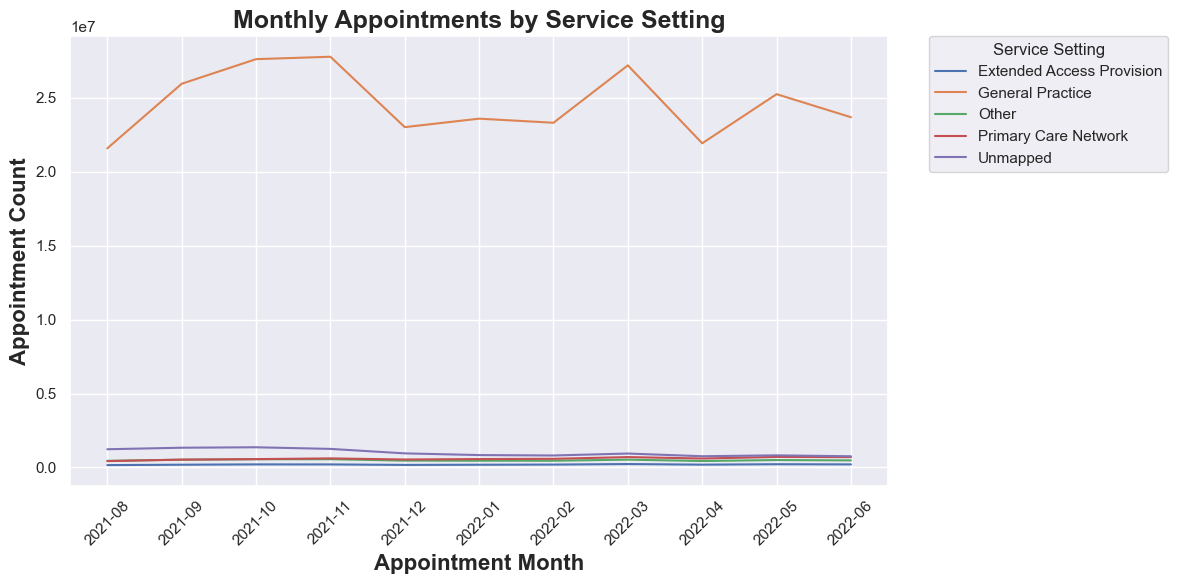

In [110]:
# Plot the appointments over the available date range, and review the service settings for months.
# Create a line plot.

nc_ss = nc.groupby(['appointment_month', 'service_setting'])['count_of_appointments'].sum()\
                  .reset_index()
sns.set_theme(style="darkgrid")
plt.figure(figsize=(12,6))
sns.lineplot(data=nc_ss, x='appointment_month', y='count_of_appointments', hue='service_setting', errorbar=None)

plt.title('Monthly Appointments by Service Setting', fontsize = 18, fontweight = 'bold')
plt.ylabel('Appointment Count', fontsize = 16, fontweight = 'bold')
plt.xlabel('Appointment Month', fontsize = 16, fontweight = 'bold')
plt.xticks(rotation=45)
plt.legend(title= 'Service Setting', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()

# View output.
plt.savefig('monthly_appointments_by_service.png', dpi = 300)
plt.show()



**Observations:**
- GPs had the highest number of total appointments.
- November 2021 had the highest number of appointments.
- Appointments fluctuate seasonally - a decline in the number of appointments from November 2021 to December 2021 (Christmas and New Year) and from March 2022 to April 2022 (Easter).

**Recommendations:**
- Review and refine the classification process of the overall service setting: identify granularity and accuracy of "Other" service setting for better mapping of data.
- Prepare for anticipated peaks in appointments: ensure service quality during high-demand months.
- Implement better data validation and staff training to minimise "Unmapped" records.
- Qualitative research to understand patient preferences (selection of "Other" during appointment booking).


**Context types:**

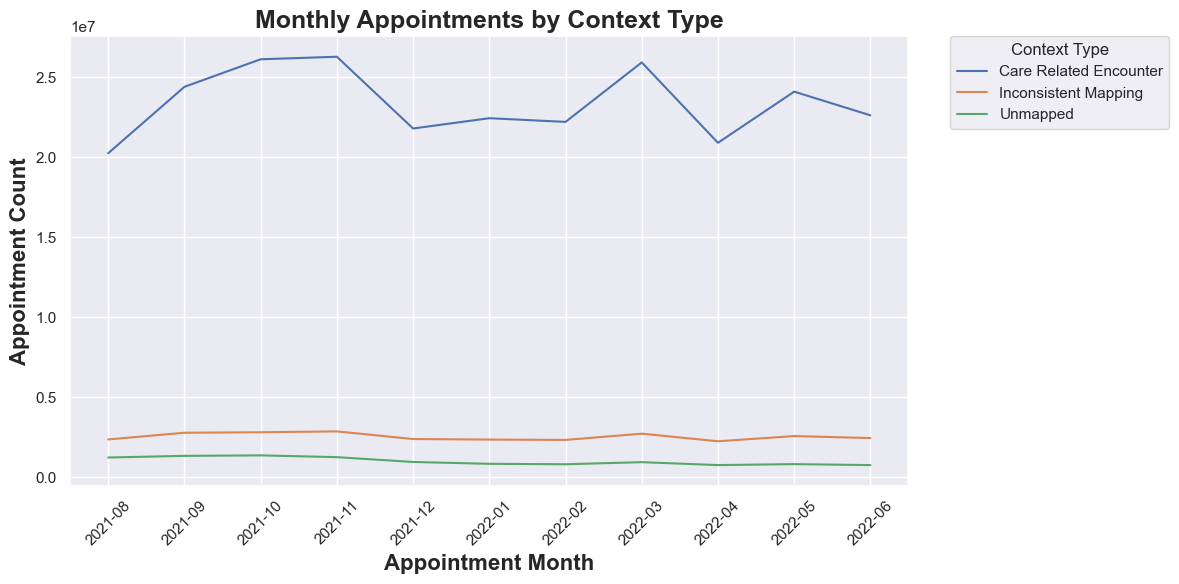

In [111]:
# Plot the appointments over the available date range, and review the context types for months.
# Create a lineplot.
# Create a separate data set that can be used in future weeks. 
nc_ct = nc.groupby(['appointment_month', 'context_type'])['count_of_appointments'].sum().reset_index()


sns.set_theme(style="darkgrid")
plt.figure(figsize =(12,6))
sns.lineplot(data = nc_ct, x= 'appointment_month', y='count_of_appointments', hue='context_type', errorbar= None)

plt.title('Monthly Appointments by Context Type', fontsize = 18, fontweight = 'bold')
plt.ylabel('Appointment Count', fontsize = 16, fontweight = 'bold')
plt.xlabel('Appointment Month', fontsize = 16, fontweight = 'bold')
plt.xticks(rotation=45)

# Place the legend outside the plot, to the right.
plt.legend(title='Context Type', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()

# View output.
plt.savefig('monthly_appointments_by_context.png', dpi = 300)
plt.show()

**Observations:**
- Care Related Encounters had the highest number of appointments.
- Seasonal fluctuations in appointments.

**Recommendations:**
- Improve data quality: implement measures to reduce the number of appointments that are mapped incorrectly.


**National categories:**

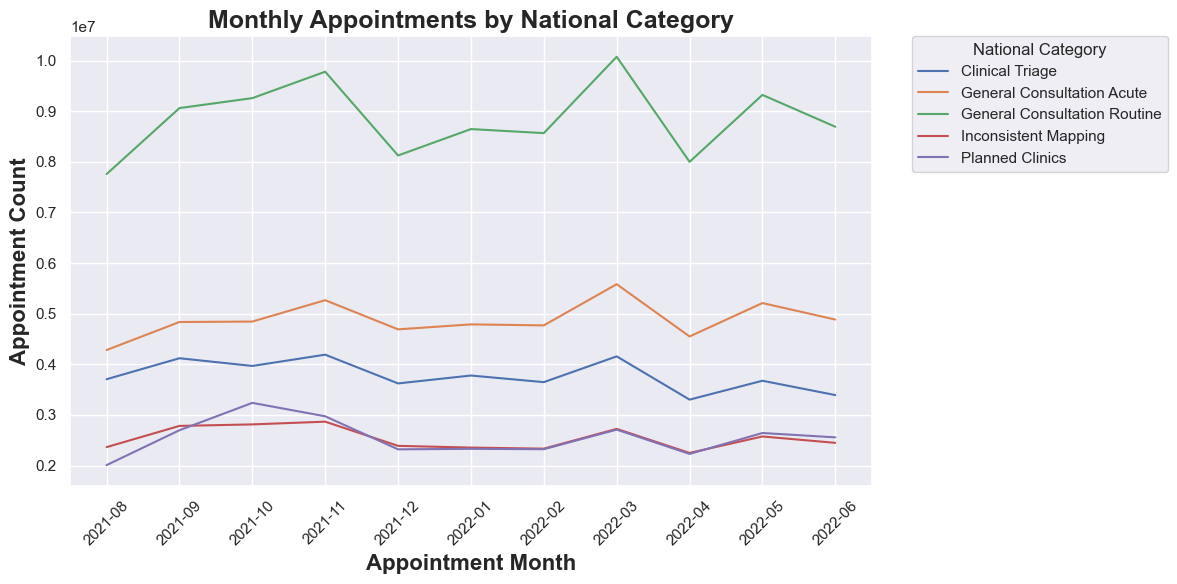

In [112]:
# Create a separate data set that can be used in future weeks. 
# Plot the appointments over the available date range, and review the national categories for months.
# Create a lineplot.

nc_nc = nc.groupby(['appointment_month', 'national_category'])['count_of_appointments'].sum().reset_index()

# Step 1: Get total appointments by national category, sort, and take the top N
N = 5  # Change this value as desired
top_categories = (
   nc_nc.groupby('national_category')['count_of_appointments']
    .sum()
    .sort_values(ascending=False)
    .head(N)
    .index
)

# Step 2: Filter the monthly_category DataFrame for only these top categories
filtered_nc_nc = nc_nc[nc_nc['national_category'].isin(top_categories)]

plt.figure(figsize=(12,6))
sns.lineplot(data=filtered_nc_nc, x='appointment_month', y='count_of_appointments', hue='national_category', errorbar=None)
plt.title('Monthly Appointments by National Category', fontsize = 18, fontweight = 'bold')
plt.ylabel('Appointment Count', fontsize = 16, fontweight = 'bold')
plt.xlabel('Appointment Month', fontsize = 16, fontweight = 'bold')
plt.xticks(rotation=45)

# Place the legend outside the plot, to the right.
plt.legend(title='National Category', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()

# View output.
plt.savefig('monthly_appointments_by_NationalCategory.png', dpi = 300)
plt.show()


**Observations:**
- General Consultation Routines were the most popular kind of appointments.
- Seasonal fluctuations affect appointment count.

### Objective 2
Create four visualisations indicating the number of appointments for service setting per season. The seasons are summer (June to August 2021), autumn (September to November 2021), winter (December to February 2022), and spring (March to May 2022).

In [113]:
# Create a separate data set that can be used in future weeks. 
import matplotlib.pyplot as plt
import seaborn as sns

nc_ss_day = nc.groupby(['appointment_month', 'service_setting'])['count_of_appointments'].sum().reset_index()

# View results to check structure.
nc_ss_day.head()


,appointment_month,service_setting,count_of_appointments
0,2021-08,Extended Access Provision,160927
1,2021-08,General Practice,21575852
2,2021-08,Other,449101
3,2021-08,Primary Care Network,432448
4,2021-08,Unmapped,1233843


In [114]:
import pandas as pd

# Altering the attributes of the nc DataFrame.
nc['appointment_date'] = pd.to_datetime(nc['appointment_date'], format='%d/%m/%Y')
nc['appointment_month'] = nc['appointment_date'].dt.to_period('M').astype(str)


# Aggregating the data.
nc_ss_day = (
    nc.groupby(['appointment_month', 'service_setting'])['count_of_appointments']
    .sum()
    .reset_index()
)

# Mapping of months to seasons
season_months = {
    "Summer": ["2021-06", "2021-07", "2021-08"],
    "Autumn": ["2021-09", "2021-10", "2021-11"],
    "Winter": ["2021-12", "2022-01", "2022-02"],
    "Spring": ["2022-03", "2022-04", "2022-05"]
}


# Seasonal and Monthly Analysis of Appointments by Service Setting
**Season Range is as follows:**
1. Summer: June to August 2021
2. Autumn: September to November 2021
3. Winter: December to February 2022
4. Spring: March to May 2022

  appointment_month            service_setting  count_of_appointments
0           2021-08  Extended Access Provision                 160927
1           2021-08           General Practice               21575852
2           2021-08                      Other                 449101
3           2021-08       Primary Care Network                 432448
4           2021-08                   Unmapped                1233843


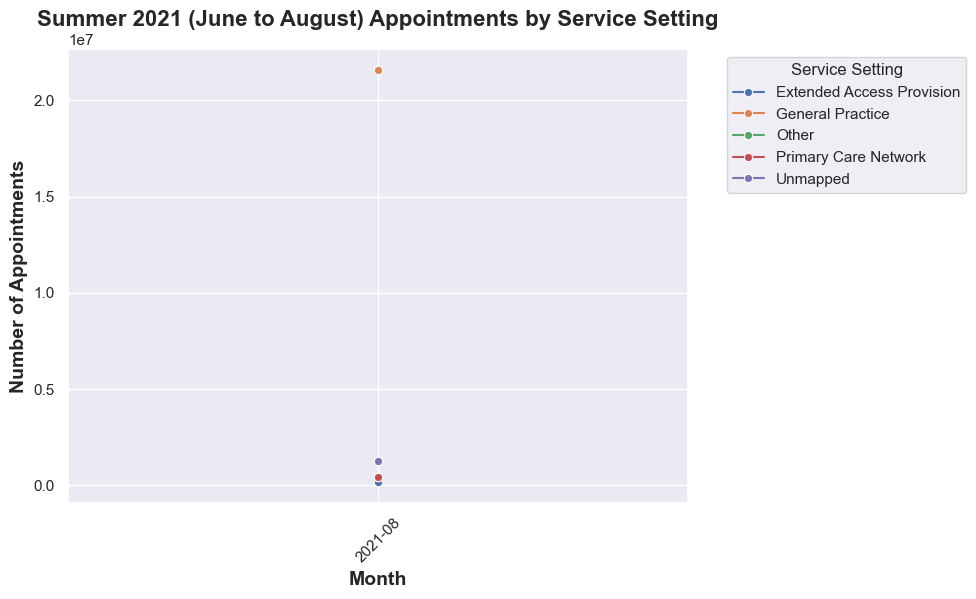

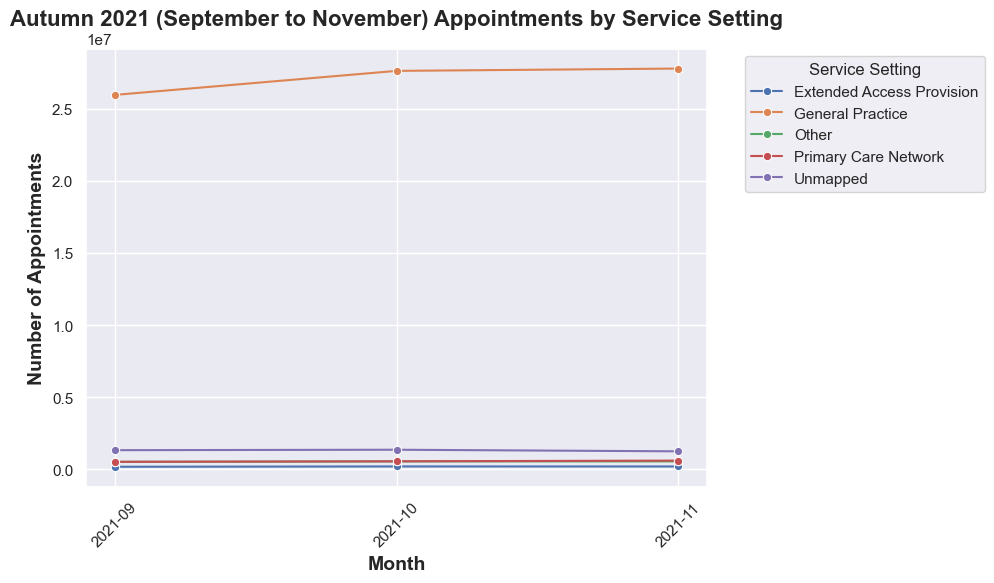

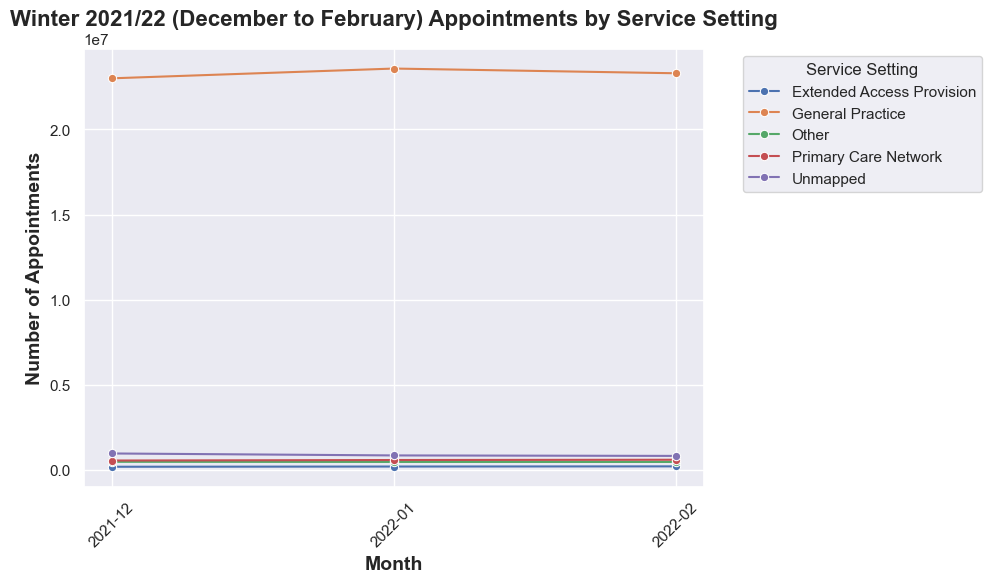

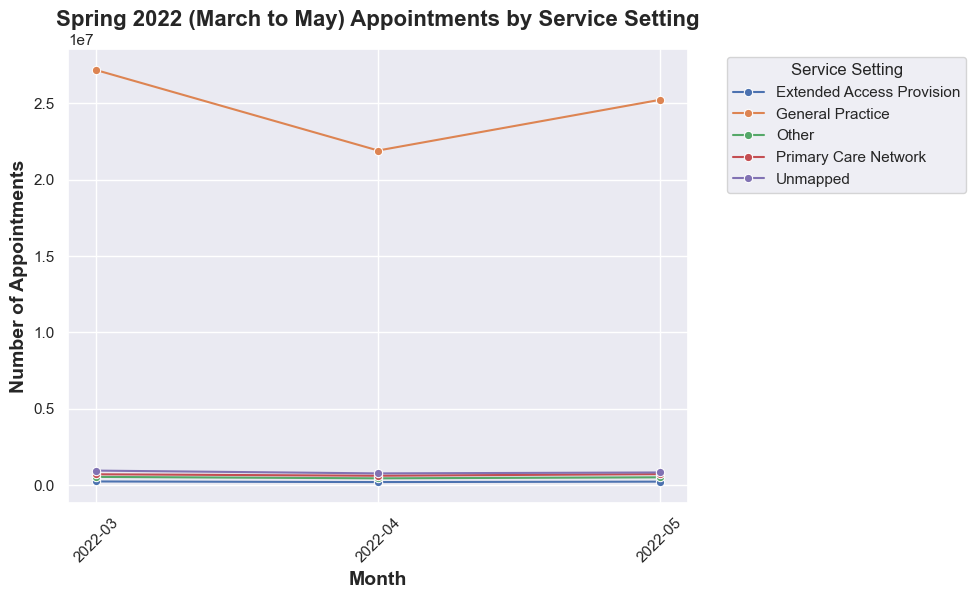

In [115]:
# Create a new DataFrame (nc_ss_day) by aggregating appointments per month and service setting
nc_ss_day = nc.groupby(['appointment_month', 'service_setting'])['count_of_appointments'].sum().reset_index()

# View the new DataFrame
print(nc_ss_day.head())

# Define the seasonal month ranges
seasons = {
    'Summer 2021': ['2021-06', '2021-07', '2021-08'],
    'Autumn 2021': ['2021-09', '2021-10', '2021-11'], 
    'Winter 2021/22': ['2021-12', '2022-01', '2022-02'],
    'Spring 2022': ['2022-03', '2022-04', '2022-05']
}

import matplotlib.pyplot as plt
import seaborn as sns

# Summer 2021
summer_df = nc_ss_day[nc_ss_day['appointment_month'].isin(['2021-06', '2021-07', '2021-08'])]
plt.figure(figsize=(10,6))
sns.lineplot(
    data=summer_df,
    x='appointment_month',
    y='count_of_appointments',
    hue='service_setting',
    marker='o',
    errorbar=None
)
plt.title('Summer 2021 (June to August) Appointments by Service Setting', fontsize = 16, fontweight = 'bold')
plt.xlabel('Month', fontsize = 14, fontweight = 'bold')
plt.ylabel('Number of Appointments', fontsize = 14, fontweight = 'bold')
plt.xticks(rotation=45)
plt.legend(title='Service Setting', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('summer_2021_appointments.png', dpi=300, bbox_inches='tight')
plt.show()

# Autumn 2021
autumn_df = nc_ss_day[nc_ss_day['appointment_month'].isin(['2021-09', '2021-10', '2021-11'])]
plt.figure(figsize=(10,6))
sns.lineplot(
    data=autumn_df,
    x='appointment_month',
    y='count_of_appointments',
    hue='service_setting',
    marker='o',
    errorbar=None
)
plt.title('Autumn 2021 (September to November) Appointments by Service Setting', fontsize = 16, fontweight = 'bold')
plt.xlabel('Month', fontsize = 14, fontweight = 'bold')
plt.ylabel('Number of Appointments', fontsize = 14, fontweight = 'bold')
plt.xticks(rotation=45)
plt.legend(title='Service Setting', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('autumn_2021_appointments.png', dpi=300, bbox_inches='tight')
plt.show()

# Winter 2021/22
winter_df = nc_ss_day[nc_ss_day['appointment_month'].isin(['2021-12', '2022-01', '2022-02'])]
plt.figure(figsize=(10,6))
sns.lineplot(
    data=winter_df,
    x='appointment_month',
    y='count_of_appointments',
    hue='service_setting',
    marker='o',
    errorbar=None
)
plt.title('Winter 2021/22 (December to February) Appointments by Service Setting', fontsize = 16, fontweight = 'bold')
plt.xlabel('Month', fontsize = 14, fontweight = 'bold')
plt.ylabel('Number of Appointments', fontsize = 14, fontweight = 'bold')
plt.xticks(rotation=45)
plt.legend(title='Service Setting', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('winter_2021_22_appointments.png', dpi=300, bbox_inches='tight')
plt.show()

# Spring 2022
spring_df = nc_ss_day[nc_ss_day['appointment_month'].isin(['2022-03', '2022-04', '2022-05'])]
plt.figure(figsize=(10,6))
sns.lineplot(
    data=spring_df,
    x='appointment_month',
    y='count_of_appointments',
    hue='service_setting',
    marker='o',
    errorbar=None
)
plt.title('Spring 2022 (March to May) Appointments by Service Setting', fontsize = 16, fontweight = 'bold')
plt.xlabel('Month', fontsize = 14, fontweight = 'bold')
plt.ylabel('Number of Appointments', fontsize = 14, fontweight = 'bold')
plt.xticks(rotation=45)
plt.legend(title='Service Setting', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('spring_2022_appointments.png', dpi=300, bbox_inches='tight')
plt.show()


**Observations:**
- GPs had the highest number of appointments of all the service settings, regardless of the season.
- Seasonal fluctuations affect appointment count. (Holiday seasons - Autumn, Winter and Spring)
- No data was collected for Summer.

**Recommendations:**
Prepare for seasonal peaks in appointments in terms of staffing capacity and demand.

# Seasonal Variation in Appointments by Service Setting (Barplot)

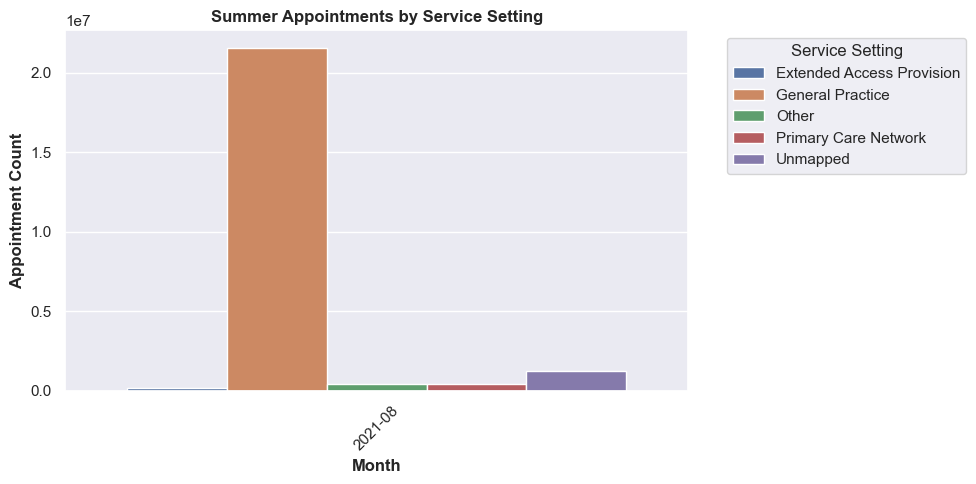

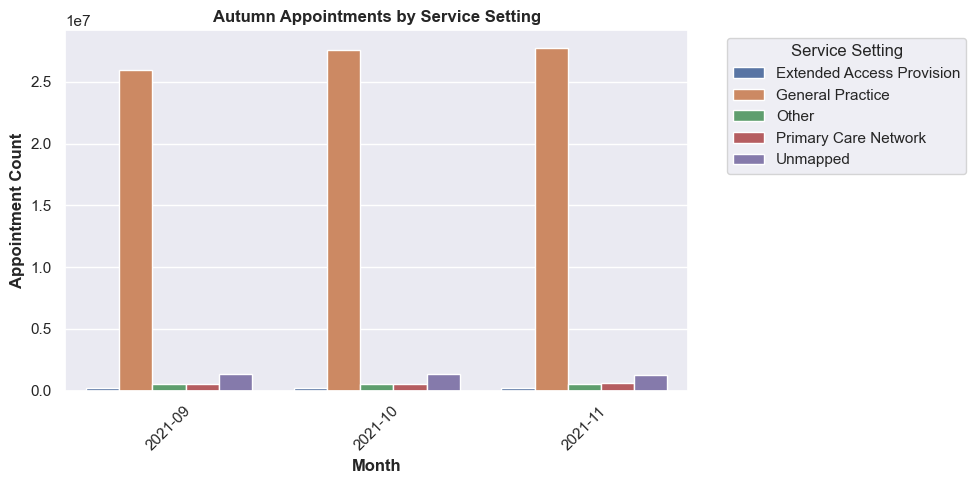

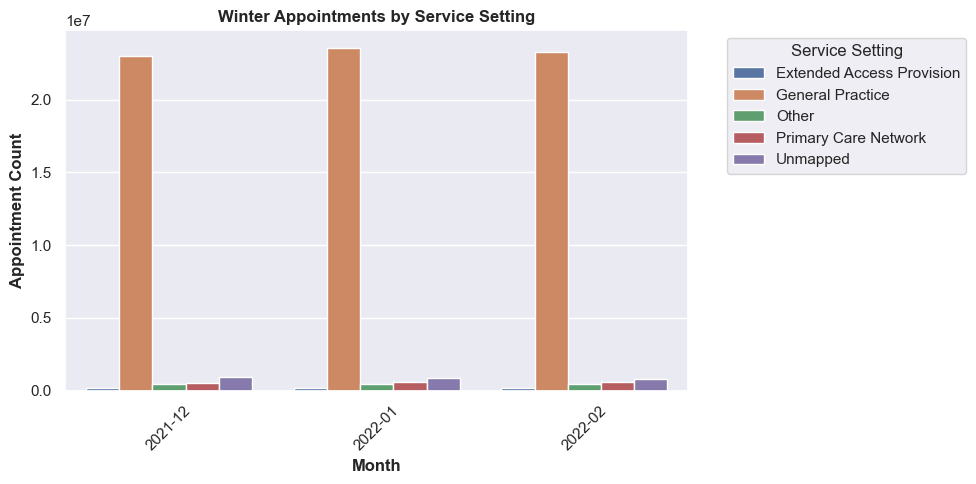

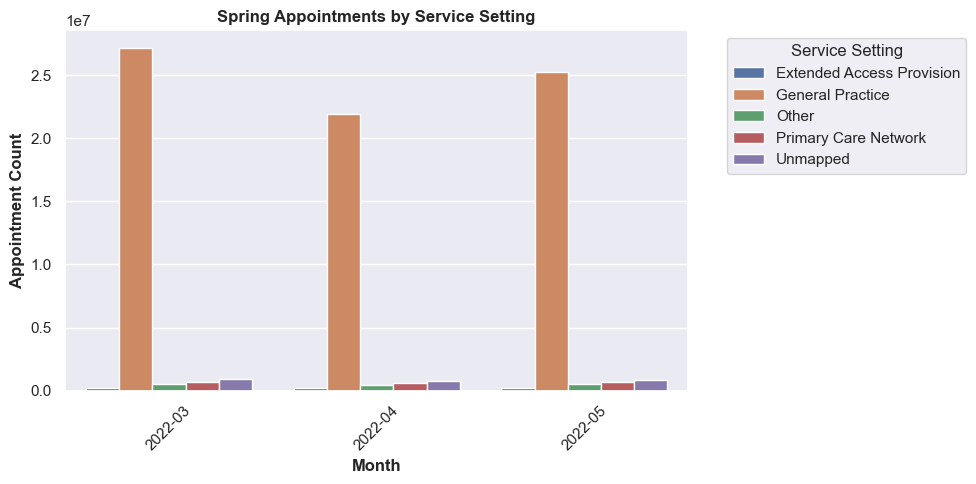

In [116]:
# Clustered Bar
import matplotlib.pyplot as plt
import seaborn as sns

for season, months in season_months.items():
    seasonal_data = nc[nc['appointment_month'].isin(months)]
    trend = (
        seasonal_data.groupby(['appointment_month', 'service_setting'])['count_of_appointments']
        .sum()
        .reset_index()
    )

    plt.figure(figsize=(10, 5))
    sns.barplot(
        data=trend,
        x='appointment_month',
        y='count_of_appointments',
        hue='service_setting'
    )

    plt.title(f'{season} Appointments by Service Setting', fontweight='bold')
    plt.ylabel('Appointment Count', fontweight='bold')
    plt.xlabel('Month', fontweight='bold')
    plt.xticks(rotation=45)
    plt.legend(title='Service Setting', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()

    # Save each plot with a unique filename per season
    plt.savefig(f'{season}_AppointmentTrend_Barplot.png', dpi=300, bbox_inches='tight')
    plt.show()

**Observations:**
- GPs had the highest number of appointments of all the service settings, regardless of the season.

# Service Setting Comparison Chart

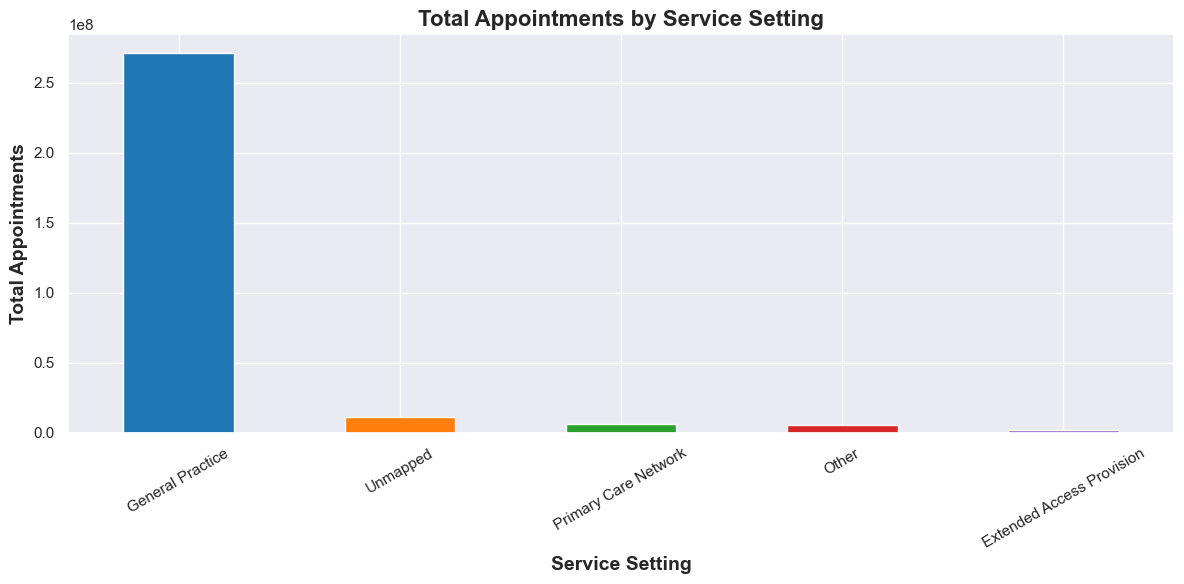

In [117]:
# Total appointments by service setting (bar chart)
service_totals = nc.groupby('service_setting')['count_of_appointments'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
service_totals.plot(kind='bar', color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', 
                                      '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf'], width = 0.5)
plt.title('Total Appointments by Service Setting', fontsize=16, fontweight='bold')
plt.xlabel('Service Setting', fontsize = 14, fontweight = 'bold')
plt.ylabel('Total Appointments', fontsize = 14, fontweight = 'bold')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('appointments_service_setting.png', dpi=300, bbox_inches='tight')
plt.show()


# Monthly Appointments Trend by Service Setting

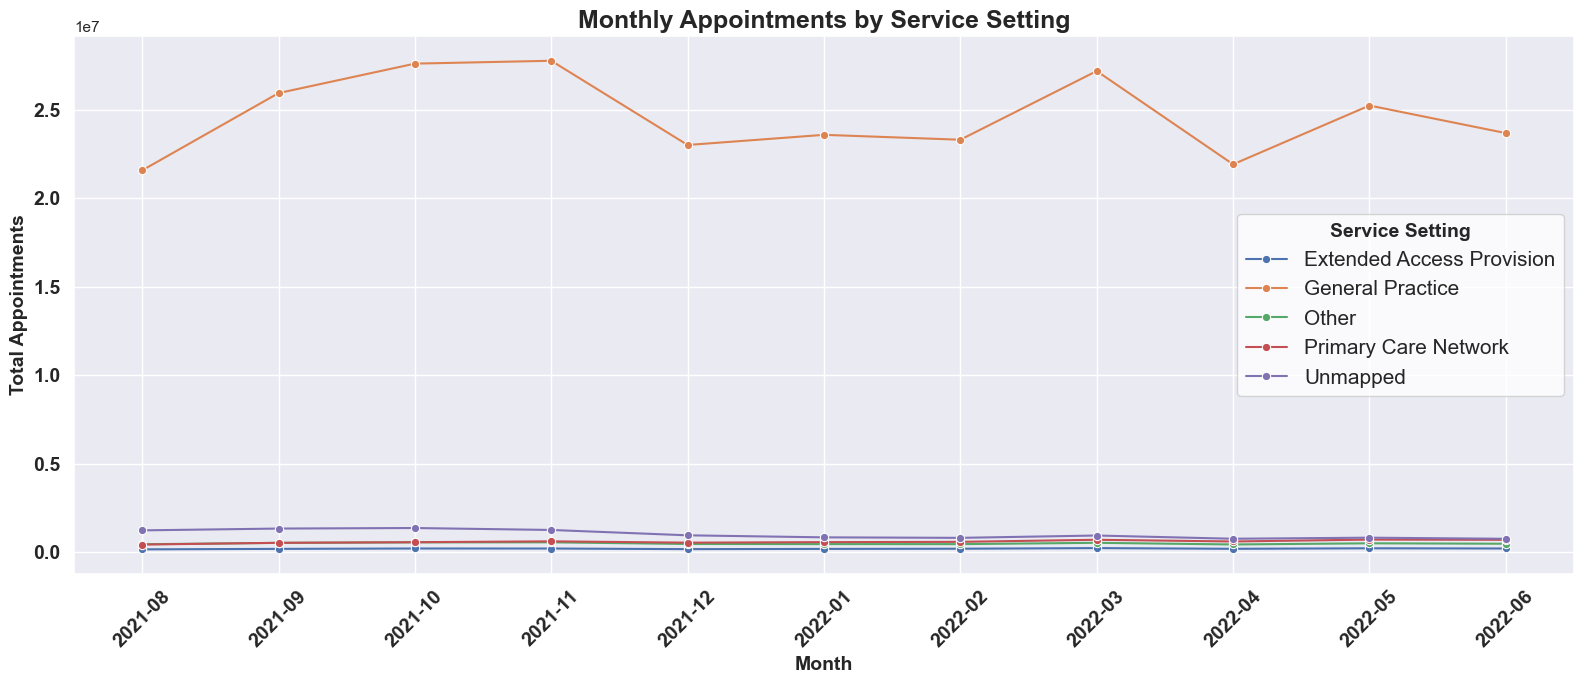

In [118]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure date column is in datetime format
nc['appointment_date'] = pd.to_datetime(nc['appointment_date'])

# Extract month for grouping
nc['month'] = nc['appointment_date'].dt.to_period('M').astype(str)

# Group by month and service setting, summing appointment counts
monthly_service_counts = (
    nc
    .groupby(['month', 'service_setting'])[['count_of_appointments']]
    .sum()
    .reset_index()
    .rename(columns={'count_of_appointments': 'Total Appointments'})
)

# Order months for x-axis
month_order = sorted(monthly_service_counts['month'].unique())

sns.set_style('darkgrid')

# View Plot.
plt.figure(figsize=(16, 7))
ax = sns.lineplot(
    data=monthly_service_counts,
    x='month',
    y='Total Appointments',
    hue='service_setting',
    marker='o'
)

plt.title('Monthly Appointments by Service Setting', fontsize=18, fontweight='bold')
plt.xlabel('Month', fontsize=14, fontweight='bold')
plt.ylabel('Total Appointments', fontsize=14, fontweight='bold')
plt.xticks(fontsize=14, rotation=45, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')
legend = plt.legend(title='Service Setting', fontsize=15, title_fontsize=14, loc='center right', facecolor = 'white')
legend.get_title().set_fontweight('bold')
plt.tight_layout()

plt.savefig('monthly_service.png', dpi = 300, bbox_inches = 'tight')
plt.show()


**GPs had the highest number of monthly appointments compared to other service settings.**

# Geographic Distribution Analysis

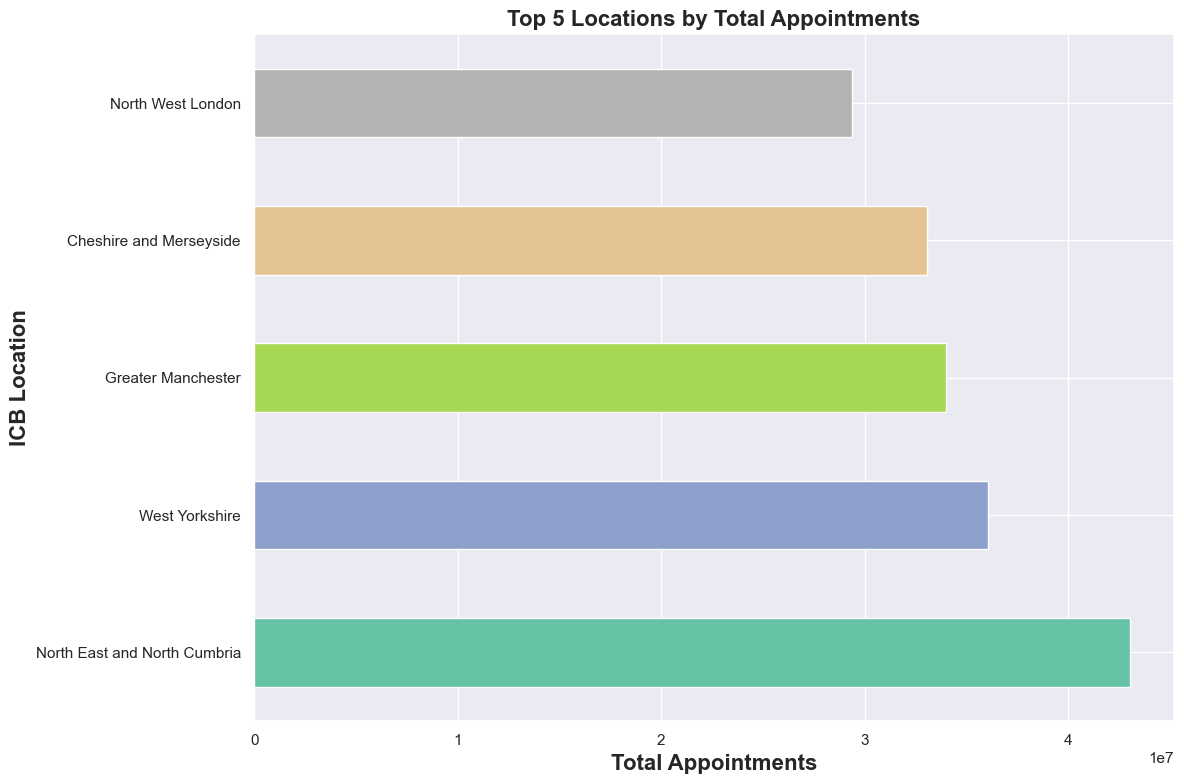

In [119]:
# Import the colourmap module
import matplotlib.cm as cm

# Mapping of ICB ONS codes to their respective location names
code_to_name = {
    'E54000050': 'North East and North Cumbria',
    'E54000054': 'West Yorkshire',
    'E54000057': 'Greater Manchester',
    'E54000008': 'Cheshire and Merseyside',
    'E54000027': 'North West London'
}

# Calculate total appointments by ICB code
location_totals = ar_unique.groupby('icb_ons_code')['count_of_appointments'].sum()

# Replace codes with names
location_totals.index = location_totals.index.map(code_to_name)

# Sort and select the top 5
top_5_locations = location_totals.sort_values(ascending= False).head(5)

# Generate a colour map with unique colours
cmap = cm.get_cmap('Set2', len(top_5_locations))
colors = [cmap(i) for i in range(len(top_5_locations))]

# Plot
plt.figure(figsize=(12, 8))
top_5_locations.plot(kind='barh', color=colors)

plt.title('Top 5 Locations by Total Appointments', fontsize=16, fontweight='bold')
plt.xlabel('Total Appointments', fontsize=16, fontweight='bold')
plt.ylabel('ICB Location', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig('top_5_locs_by_appointments_named.png', dpi=300, bbox_inches='tight')
plt.show()

**Observations:**
- North East and North Cumbria had the highest number of appointments overall.

**Recommendations:**
- Investigate the reason behind the North East and North Cumbria ICB achieving the highest appointment volume. Assess the factors responsible for this and adopt a similar model of best practices across other regions.

# Context Type Distribution

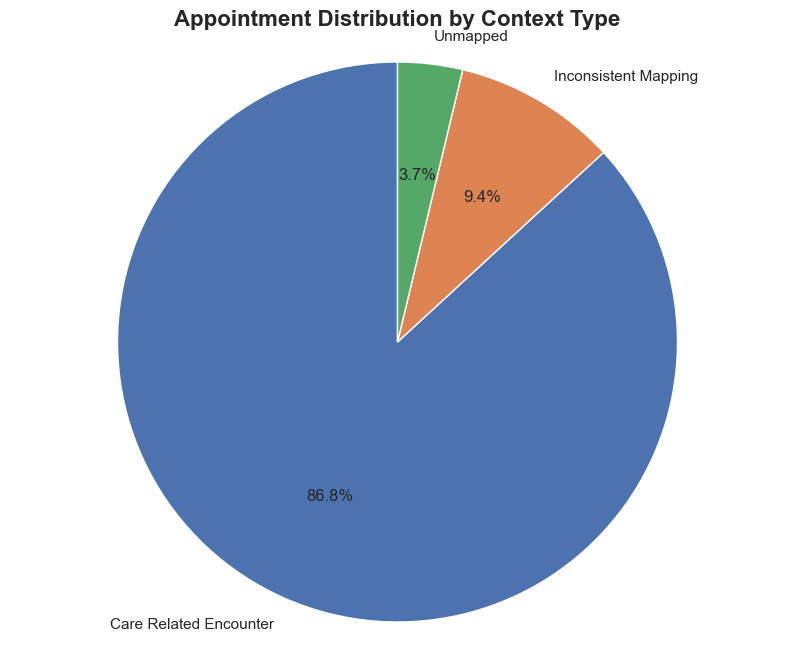

In [120]:
# Pie chart showing appointment distribution by context type
context_totals = nc.groupby('context_type')['count_of_appointments'].sum()

plt.figure(figsize=(10, 8))
plt.pie(context_totals.values, labels=context_totals.index, autopct='%1.1f%%', startangle=90)
plt.title('Appointment Distribution by Context Type', fontsize=16, fontweight='bold')
plt.axis('equal')
plt.savefig('context_type_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


# National Category Performance

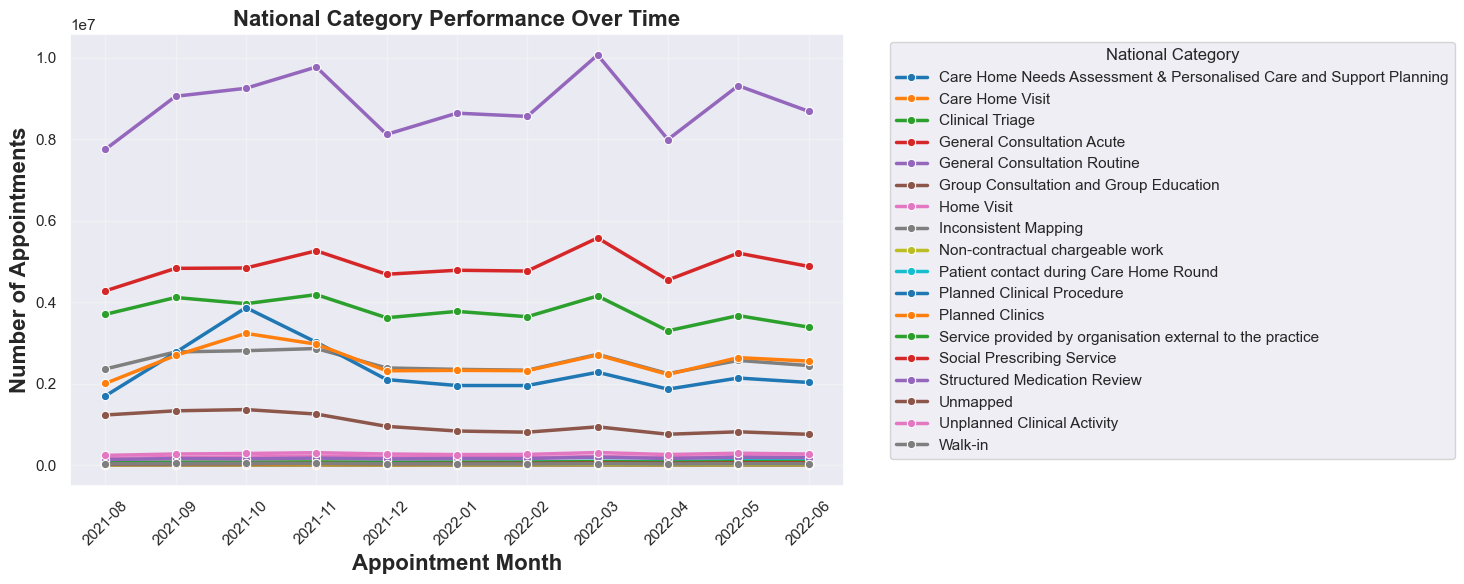

In [121]:
# Compare national categories over time
national_monthly = nc.groupby(['appointment_month', 'national_category'])['count_of_appointments'].sum().reset_index()

plt.figure(figsize=(15, 6))
sns.lineplot(data=national_monthly, x='appointment_month', y='count_of_appointments', 
             hue='national_category', palette= 'tab10', marker='o', linewidth=2.5)
plt.title('National Category Performance Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Appointment Month', fontsize=16, fontweight='bold')
plt.ylabel('Number of Appointments', fontsize=16, fontweight='bold')
plt.xticks(rotation=45)
plt.legend(title='National Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig('NC performance over time.png', dpi= 600, bbox_inches='tight') 
plt.show()


# Performance of the Top 5 National Categories Over Time

Top 5 National Categories by Total Appointments:
               national_category  count_of_appointments
4   General Consultation Routine               97271522
3     General Consultation Acute               53691150
2                Clinical Triage               41546964
11               Planned Clinics               28019748
7           Inconsistent Mapping               27890802


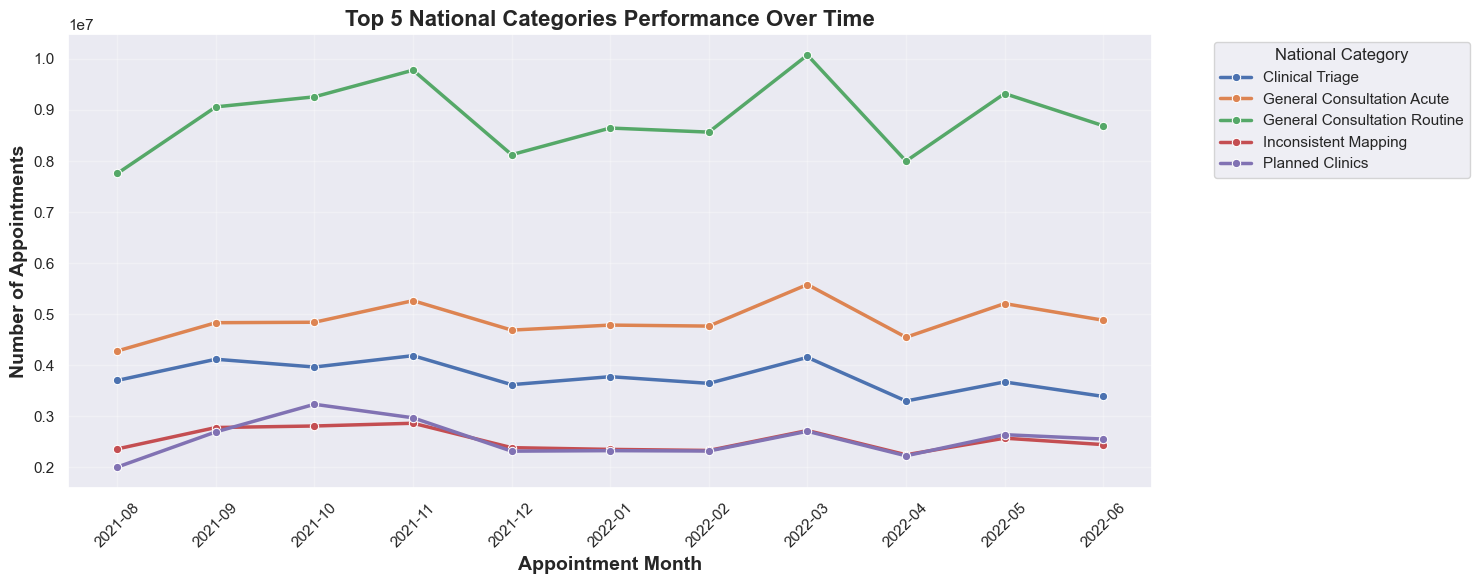


Top 5 categories represent 83.9% of all appointments

Detailed breakdown:
               national_category  count_of_appointments  percentage
4   General Consultation Routine               97271522       32.86
3     General Consultation Acute               53691150       18.14
2                Clinical Triage               41546964       14.03
11               Planned Clinics               28019748        9.46
7           Inconsistent Mapping               27890802        9.42


In [122]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Identify top 5 national categories by total appointments
total_by_national = nc.groupby('national_category')['count_of_appointments'].sum().reset_index()
top_5_categories = total_by_national.sort_values(by='count_of_appointments', ascending=False).head(5)['national_category'].tolist()

print("Top 5 National Categories by Total Appointments:")
print(total_by_national.sort_values(by='count_of_appointments', ascending=False).head(5))

# Step 2: Filter the monthly data to include only top 5 categories
national_monthly = nc.groupby(['appointment_month', 'national_category'])['count_of_appointments'].sum().reset_index()
national_monthly_top5 = national_monthly[national_monthly['national_category'].isin(top_5_categories)]

# Step 3: Create the plot with only top 5 categories
plt.figure(figsize=(15, 6))
sns.lineplot(data=national_monthly_top5, 
             x='appointment_month', 
             y='count_of_appointments', 
             hue='national_category', 
             marker='o', 
             linewidth=2.5,
             markersize=6)
plt.title('Top 5 National Categories Performance Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Appointment Month', fontsize=14, fontweight = 'bold')
plt.ylabel('Number of Appointments', fontsize=14, fontweight = 'bold')
plt.xticks(rotation=45)
plt.legend(title='National Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig('Top 5 Nc Over Time.png', dpi=300, bbox_inches='tight')
plt.show()

# Optional: Show the percentage each top 5 category represents
total_all_appointments = nc['count_of_appointments'].sum()
top_5_percentages = total_by_national.sort_values(by='count_of_appointments', ascending=False).head(5)
top_5_percentages['percentage'] = (top_5_percentages['count_of_appointments'] / total_all_appointments * 100).round(2)

print(f"\nTop 5 categories represent {top_5_percentages['percentage'].sum():.1f}% of all appointments")
print("\nDetailed breakdown:")
print(top_5_percentages[['national_category', 'count_of_appointments', 'percentage']])


# Overall Monthly Appointments Trend Line

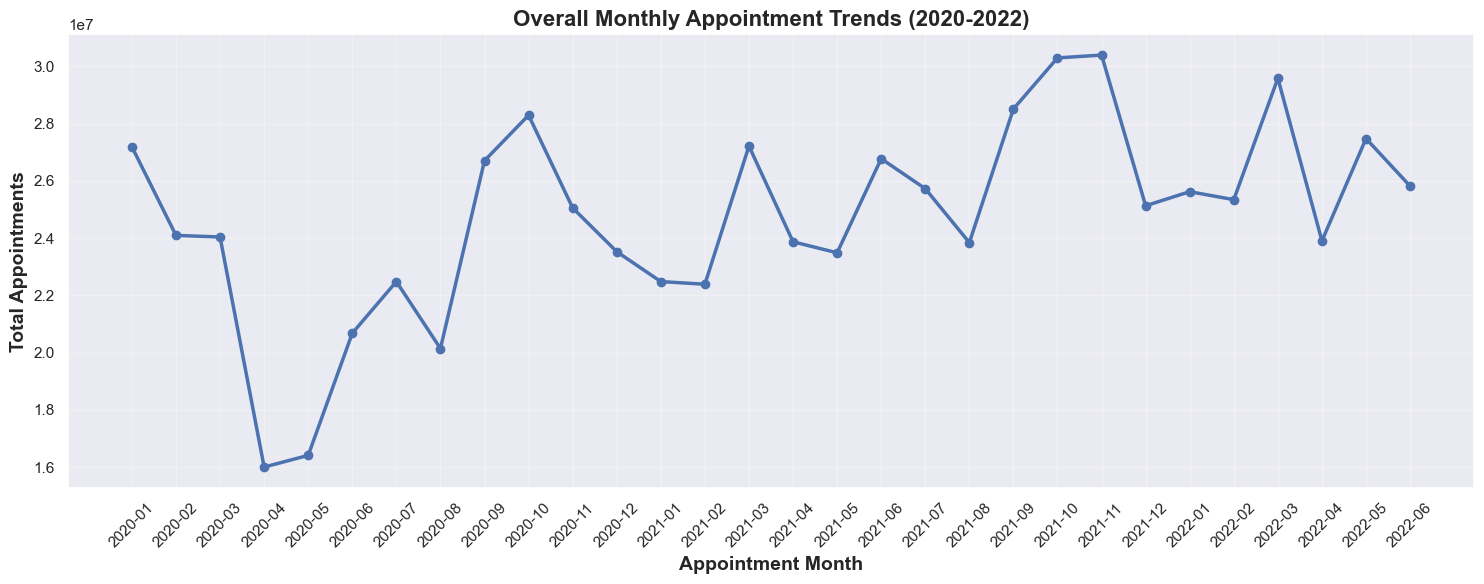

In [123]:
# Overall monthly trend across all services
monthly_total = ar_unique.groupby('appointment_month')['count_of_appointments'].sum()

plt.figure(figsize=(15, 6))
plt.plot(monthly_total.index, monthly_total.values, marker='o', linewidth=2.5, markersize=6)
plt.title('Overall Monthly Appointment Trends (2020-2022)', fontsize=16, fontweight='bold')
plt.xlabel('Appointment Month', fontsize=14, fontweight='bold')
plt.ylabel('Total Appointments', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('overall_monthly_trends_line.png', dpi=600, bbox_inches='tight')
plt.show()


Trend Identification: Allows you to spot overall increases or decreases in NHS activity, showing effects of external factors (e.g., COVID-19 waves, seasonal changes/demands, etc).
1. System Shocks & Recovery: Any sharp dips or spikes are evidence of events impacting the whole system.
2. Strategic Use:
	- Sustained upward trends may indicate rising demand, signalling the need for additional capacity.
	- Downward trends or plateaus might point to system bottlenecks, reduced patient access, or seasonal dips.

# Overall Capacity Utilisation Trend

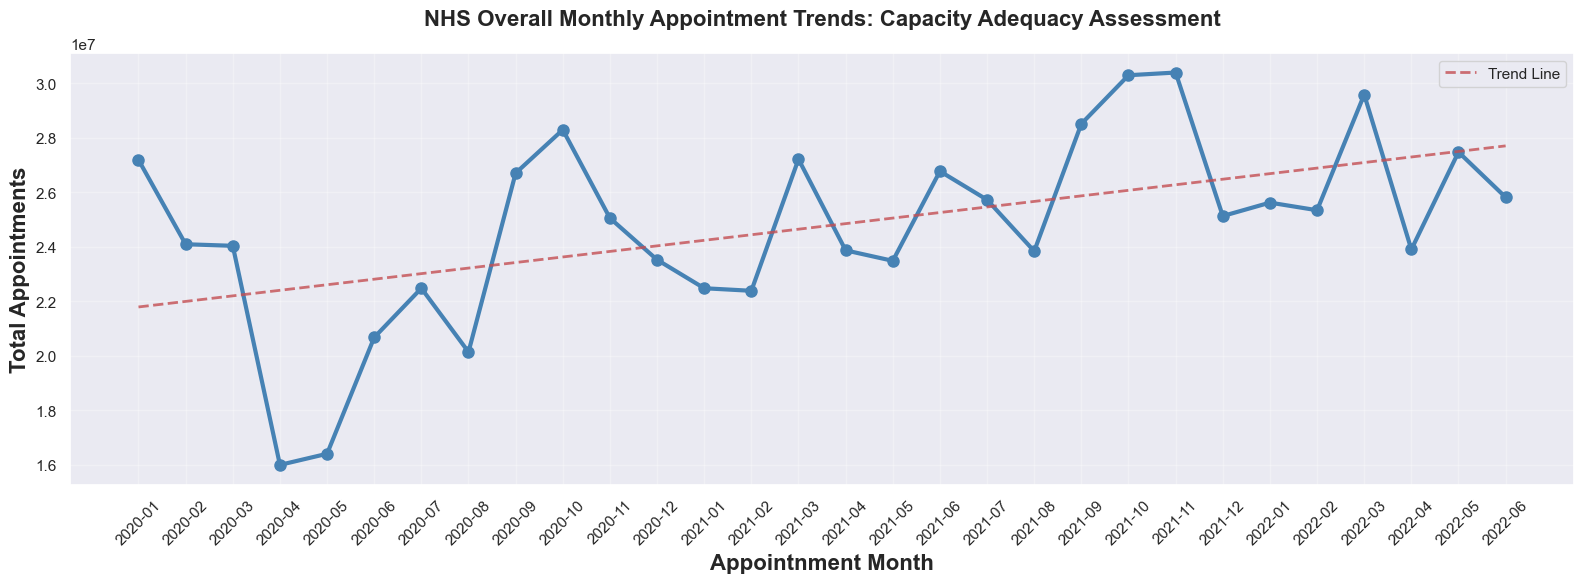

Average monthly growth rate: 0.85%


In [124]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Overall monthly trend to assess capacity adequacy
monthly_total = ar_unique.groupby('appointment_month')['count_of_appointments'].sum().reset_index()

plt.figure(figsize=(16, 6))
plt.plot(monthly_total['appointment_month'], monthly_total['count_of_appointments'], 
         marker='o', linewidth=3, markersize=8, color='steelblue')
plt.title('NHS Overall Monthly Appointment Trends: Capacity Adequacy Assessment', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Appointnment Month', fontsize=16, fontweight='bold')
plt.ylabel('Total Appointments', fontsize=16, fontweight='bold')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Add trend line
z = np.polyfit(range(len(monthly_total)), monthly_total['count_of_appointments'], 1)
p = np.poly1d(z)
plt.plot(monthly_total['appointment_month'], p(range(len(monthly_total))), 
         "r--", alpha=0.8, linewidth=2, label='Trend Line')
plt.legend()
plt.tight_layout()
plt.savefig('Overall Capacity Utilization Trend.png', dpi = 300, bbox_inches = 'tight')
plt.show()

# Calculate growth rate
monthly_total['growth_rate'] = monthly_total['count_of_appointments'].pct_change() * 100
avg_growth = monthly_total['growth_rate'].mean()
print(f"Average monthly growth rate: {avg_growth:.2f}%")


Key Insights & Patterns:
1. Capacity Strain Indicators: Sharp upward trends suggest demand exceeding capacity
2. Seasonal Bottlenecks: November 2021 had the highest appointment volume
3. Growth Trajectory: A Positive trend indicates increasing demand on NHS resources
4. Peak Periods: Jan 2020, March 2020, October 2020, March 2021, June 2021, November 2021, and March 2022 were a few months that experienced peak volumes of appointments, which indicate the demand for additional staffing and infrastructure

Business Implications:
1. Sustained growth above 5% monthly indicates inadequate capacity
2. Steep increases suggest an urgent need for staff expansion
3. Stable/declining trends may indicate adequate current capacity

# Missed appointment based on the time between booking and the appointment

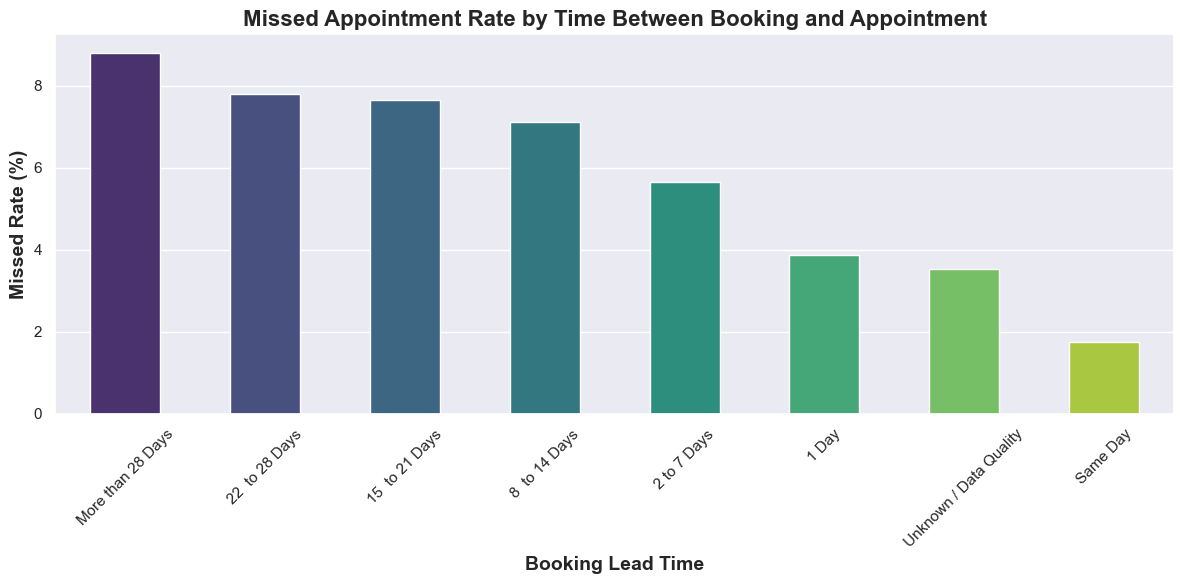

In [125]:
cols = ['appointment_status', 'time_between_book_and_appointment', 'count_of_appointments']
ar_filtered = ar_unique[cols]

# Sum appointments per status and delay range
grouped = ar_filtered.groupby(['time_between_book_and_appointment', 'appointment_status'])['count_of_appointments'].sum().unstack().fillna(0)

# Calculate total and missed rate
grouped['Total'] = grouped.sum(axis=1)
grouped['Missed Rate (%)'] = (grouped.get('DNA', 0) / grouped['Total']) * 100

# Reset index for plotting
grouped = grouped.reset_index().sort_values(by='Missed Rate (%)', ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(data=grouped, 
            x='time_between_book_and_appointment', 
            y='Missed Rate (%)', 
            palette='viridis',
            width=0.5)
# Plot.
plt.title('Missed Appointment Rate by Time Between Booking and Appointment', fontsize=16, fontweight='bold')
plt.xlabel('Booking Lead Time', fontsize=14, fontweight='bold')
plt.ylabel('Missed Rate (%)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('missed_appointment_by_booking_time.png', dpi = 300, bbox_inches = 'tight')
plt.show()


**Observations:**
- Missed Rate of appointments is higher when the gap between the booking time and appointment date is long.
- Same-day appointments have the lowest missed appointment rate, while appointments that had a wait time of more than 28 days had a higher missed appointment rate.

**Recommendations:**
- Promote shorter booking windows.
- Implement reminder systems: automated reminder messages (via SMA, email or phone).
- Offer easy rescheduling options: Provide user-friendly ways for patients to reschedule or cancel if they anticipate missing.

# Missed Appointments by booking lead time and appointment mode

1. Shorter lead times (Same Day, 1 Day) are associated with lower DNA rates across modes.

2. Face-to-Face and Home Visit appointments booked far in advance show significantly higher missed rates.

3. Telephone appointments maintain moderate DNA rates across time buckets — could indicate they’re more flexible or convenient.

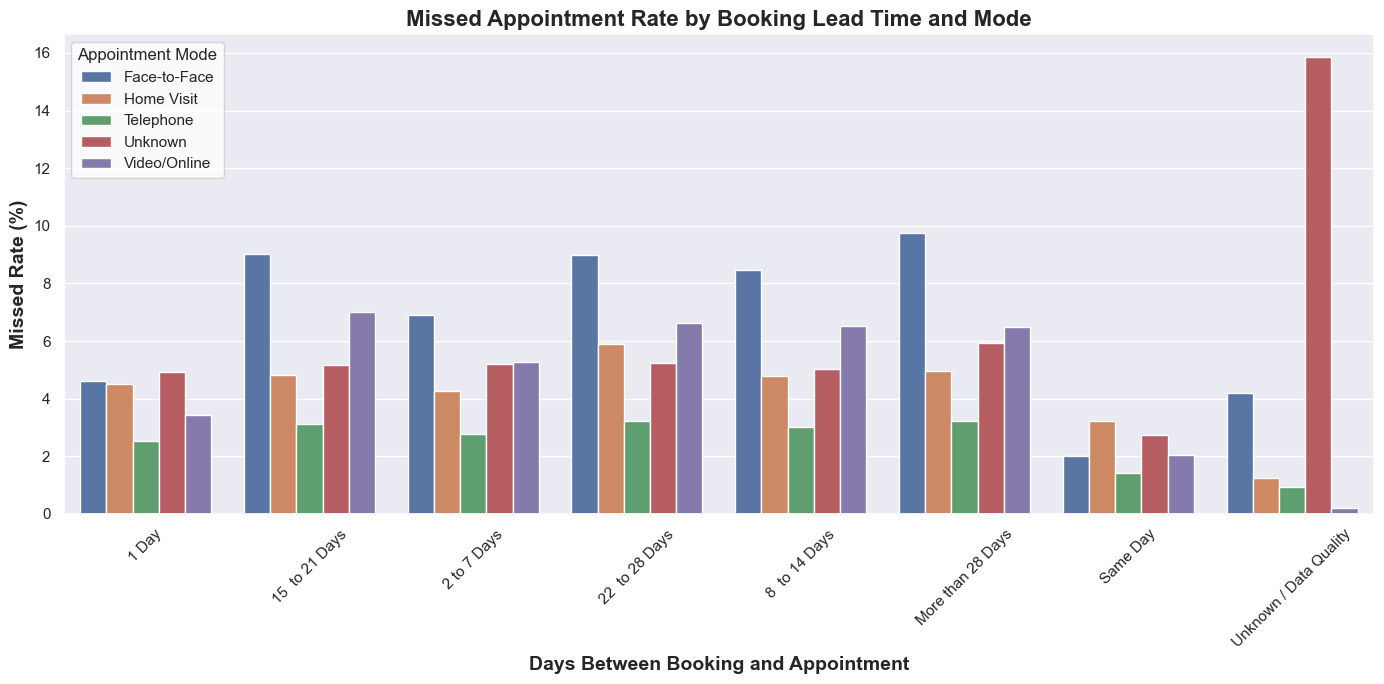

In [126]:
import seaborn as sns
import matplotlib.pyplot as plt

# Group by both time gap and appointment mode
mode_grouped = ar_unique.groupby(['time_between_book_and_appointment', 'appointment_mode', 'appointment_status'])['count_of_appointments'].sum().unstack(fill_value=0)

# Compute total and missed rate
mode_grouped['Total'] = mode_grouped.sum(axis=1)
mode_grouped['Missed Rate (%)'] = (mode_grouped.get('DNA', 0) / mode_grouped['Total']) * 100
mode_grouped = mode_grouped.reset_index()


# Plot
plt.figure(figsize=(14,7))
sns.barplot(data=mode_grouped, 
            x='time_between_book_and_appointment', 
            y='Missed Rate (%)', 
            hue='appointment_mode',
            )

plt.xticks(rotation=45)
plt.title('Missed Appointment Rate by Booking Lead Time and Mode', fontsize=16, fontweight='bold')
plt.xlabel('Days Between Booking and Appointment', fontsize=14, fontweight='bold')
plt.ylabel('Missed Rate (%)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.legend(title='Appointment Mode', facecolor = 'white')
plt.savefig('Missed book and Mode.png' , dpi = 300, bbox_inches = 'tight')
plt.show()


**Observations:**
- Unknown data is high in number.
- Face-to-Face appointments show high missed rates.
- Video/Oline appointments have the second-highest missed rates.
- Telephonic consultations have the lowest appointment missed rates.

**Recommendations:**
- Improve data quality: ensure there is a lower number of unknown data points that are entered in the system.
- Provide regular/prompt reminders to patients who have booked video/online consultations to avoid missed appointments.
- Encourage Telephonic consultations.

# Missed Appointments by Booking Lead Time & HCP Type

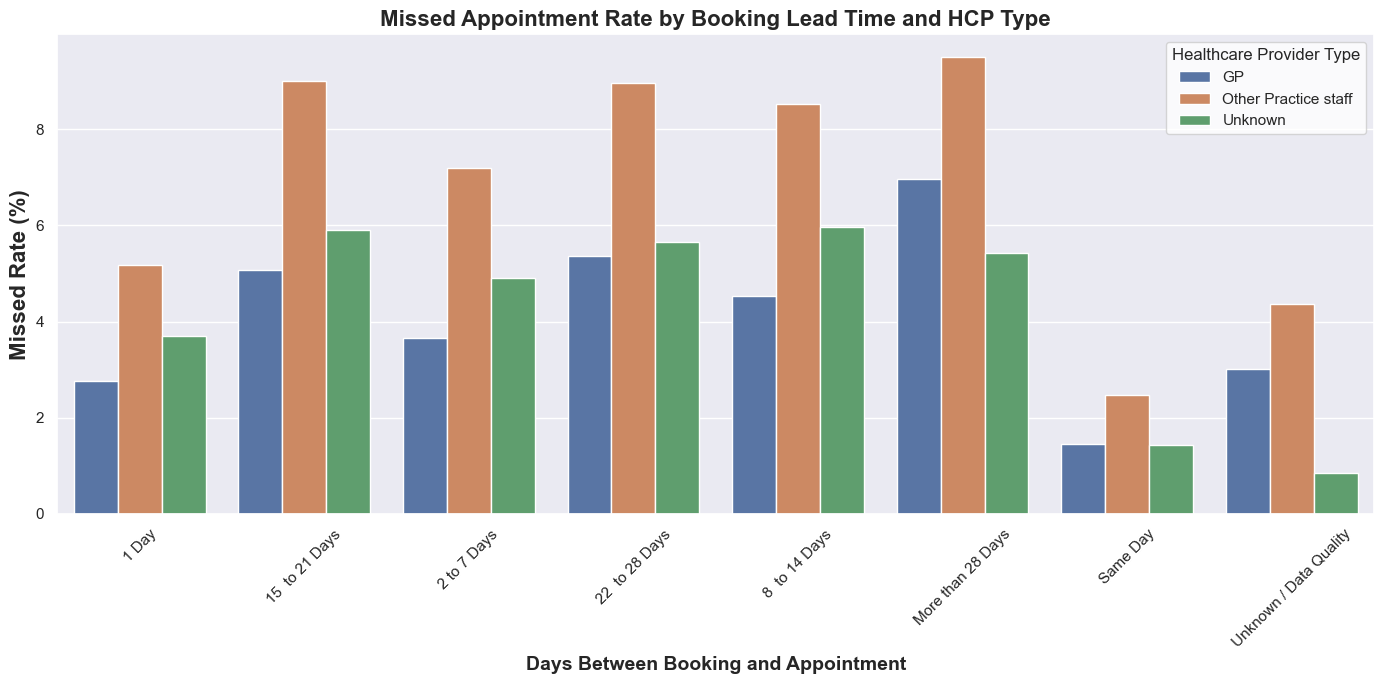

In [127]:
# Group by time gap and hcp_type
hcp_grouped = ar_unique.groupby(['time_between_book_and_appointment', 'hcp_type', 'appointment_status'])['count_of_appointments'].sum().unstack(fill_value=0)

# Compute total and missed rate
hcp_grouped['Total'] = hcp_grouped.sum(axis=1)
hcp_grouped['Missed Rate (%)'] = (hcp_grouped.get('DNA', 0) / hcp_grouped['Total']) * 100
hcp_grouped = hcp_grouped.reset_index()

# Plot
plt.figure(figsize=(14,7))
sns.barplot(data=hcp_grouped, x='time_between_book_and_appointment', y='Missed Rate (%)', hue='hcp_type')
plt.xticks(rotation=45)
plt.title('Missed Appointment Rate by Booking Lead Time and HCP Type', fontsize=16, fontweight='bold')
plt.xlabel('Days Between Booking and Appointment', fontsize=14, fontweight='bold')
plt.ylabel('Missed Rate (%)', fontsize=16, fontweight='bold')
plt.legend(title='Healthcare Provider Type', facecolor = 'white')
plt.tight_layout()

plt.savefig('Missed Appointment Rate by booking grouped bar HCP Type.png', dpi = 300, bbox_inches = 'tight')
plt.show()


**Observations:**
- Same-day appointments have low missed appointment rates
- GPs have the lowest missed rates
- Appointments taken by other practice staff have the highest missed rates

# Number of Missed Appointments by Region

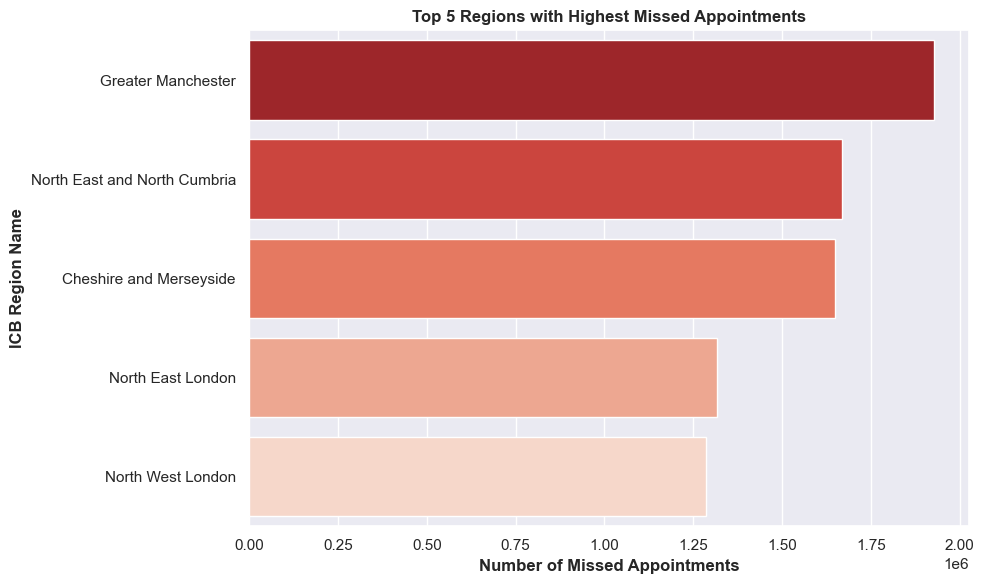

In [128]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Example filter from your code
missed_appt = ar_unique[ar_unique['appointment_status'] == 'DNA']

# Group by region
top_regions = (
    missed_appt.groupby('icb_ons_code')['count_of_appointments']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .reset_index()
)

# Assigning region names to ICB ons Codes
region_map = {
    'E54000057': 'Greater Manchester',
    'E54000050': 'North East and North Cumbria',
    'E54000008': 'Cheshire and Merseyside',
    'E54000029': 'North East London',
    'E54000027': 'North West London'
}
top_regions['region_name'] = top_regions['icb_ons_code'].map(region_map)

# Plot with region names
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_regions,
    x='count_of_appointments',
    y='region_name',
    palette='Reds_r'
)
plt.title('Top 5 Regions with Highest Missed Appointments', fontweight='bold')
plt.xlabel('Number of Missed Appointments', fontweight = 'bold')
plt.ylabel('ICB Region Name', fontweight = 'bold')
plt.tight_layout()
plt.savefig('ICB Region vs Missed Appointments.png', dpi = 300, bbox_inches = 'tight')
plt.show()


**Observations:**
The Greater Manchester ICB region had the highest number of missed appointments

**Recommendations:**
- Reminders (SMS, email, calls) to avoid missing appointments.
- Research underlying causes in the cities with high rates of missed appointments - explore transport, socioeconomic barriers and communication issues.
- Strengthen and automate reminders across all high-miss regions.
- Monitoring missed appointment rates at the regional and sub-regional level to evaluate which initiatives lead to tangible reductions.


# Number of Attended Appointments by Region

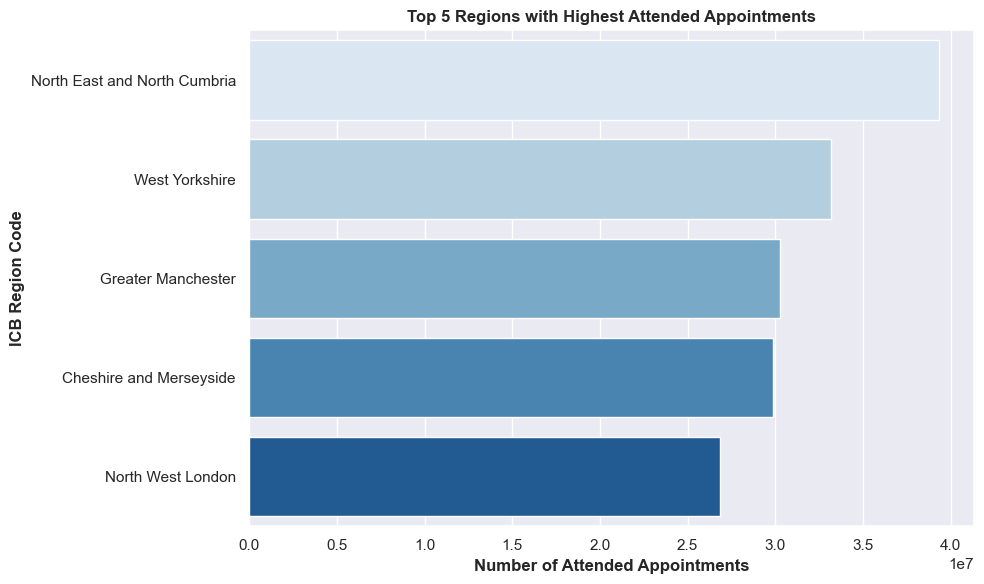

In [129]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Example filter from your code
attended_appt = ar_unique[ar_unique['appointment_status'] == 'Attended']

# Group by region
top_region = (
  attended_appt.groupby('icb_ons_code')['count_of_appointments']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .reset_index()
)

# Assigning region names to ICB ons Codes
regions_map = {
    'E54000057': 'Greater Manchester',
    'E54000050': 'North East and North Cumbria',
    'E54000008': 'Cheshire and Merseyside',
    'E54000054': 'West Yorkshire',
    'E54000027': 'North West London'
}
top_region['region_names'] = top_region['icb_ons_code'].map(regions_map)

# Plot with ICB codes instead of region names
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_region,
    x='count_of_appointments',
    y='region_names',  
    palette='Blues'
)
plt.title('Top 5 Regions with Highest Attended Appointments', fontweight='bold')
plt.xlabel('Number of Attended Appointments', fontweight='bold')
plt.ylabel('ICB Region Code', fontweight='bold')  
plt.tight_layout()
plt.savefig('ICB Region vs Attennded Appointments.png', dpi=300, bbox_inches='tight')
plt.show()

**Observations:**
North East and North Cumbria had the highest appointment attendance rate.

# Appointments by Weekday Dominance

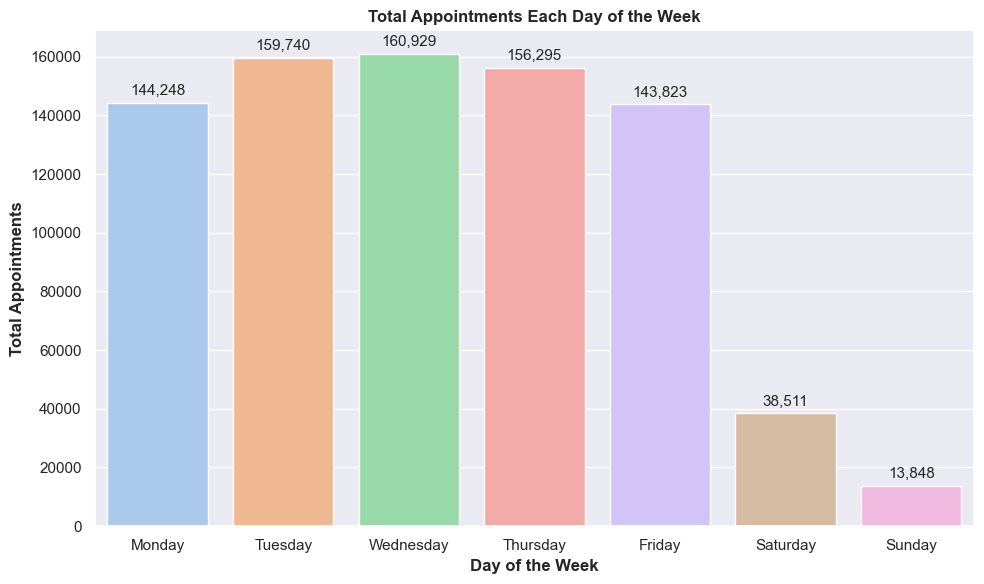

In [130]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure appointment_date is in datetime format
nc['appointment_date'] = pd.to_datetime(nc['appointment_date'])

# Create weekday index and label columns
nc['Day Index'] = nc['appointment_date'].dt.dayofweek  # 0=Monday
nc['Day Name'] = nc['appointment_date'].dt.day_name()

# Count total appointments by day index (preserves correct order)
day_counts = nc.groupby('Day Index').size().reset_index(name='Total Appointments')

# Set friendly weekday labels
weekday_labels = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

sns.set_style('darkgrid')
plt.figure(figsize=(10, 6))
barplot = sns.barplot(x='Day Index', y='Total Appointments', data=day_counts, palette='pastel')

# Custom x labels
barplot.set_xticklabels(weekday_labels)

# Add count labels above each bar
for idx, row in day_counts.iterrows():
    barplot.text(idx, row['Total Appointments'] + max(day_counts['Total Appointments']) * 0.01,
                 f"{row['Total Appointments']:,}", ha='center', va='bottom', fontsize=11)

plt.title('Total Appointments Each Day of the Week', fontweight = 'bold')
plt.xlabel('Day of the Week', fontweight = 'bold')
plt.ylabel('Total Appointments', fontweight = 'bold')
plt.tight_layout()

plt.savefig('Appointments_Weekday.png', dpi = 300, bbox_inches = 'tight')
plt.show()



**This visual makes it clear that appointments are heavily concentrated on weekdays. There is a significant drop on Saturdays and Sundays. While Wednesdays and Tuesdays have the highest number of appointments, making mid-week very popular for appointments.**

# Overall Weekly Appointment Trends Aug 2021 - Jun 2022

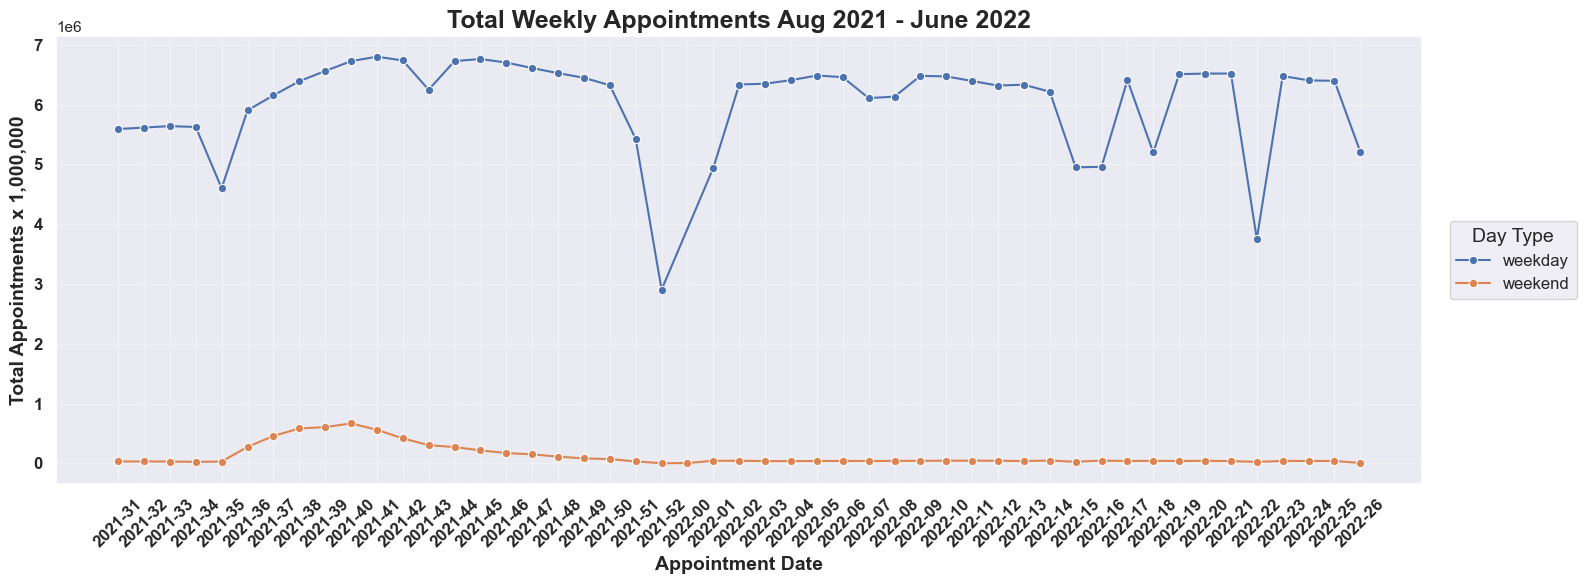

In [131]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert date column to datetime
nc['appointment_date'] = pd.to_datetime(nc['appointment_date'], dayfirst=True)

# Create a week number and year-week column 
nc['year_week'] = nc['appointment_date'].dt.strftime('%Y-%U')

# Classify weekdays and weekends
nc['day_type'] = nc['appointment_date'].dt.weekday.apply(lambda x: 'weekend' if x >= 5 else 'weekday')

# Group by week and day type
weekly = (
    nc.groupby(['year_week', 'day_type'])['count_of_appointments']
    .sum()
    .reset_index()
    .sort_values(by='year_week')
)

# Plot the chart

sns.set_style('darkgrid')
plt.figure(figsize=(16, 6))

sns.lineplot(
    data=weekly,
    x='year_week',
    y='count_of_appointments',
    hue='day_type',
    marker='o'
)
plt.title('Total Weekly Appointments Aug 2021 - June 2022', fontsize=18, fontweight='bold')
plt.xlabel('Appointment Date', fontsize=14, fontweight='bold')
plt.ylabel('Total Appointments x 1,000,000', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')

plt.legend(
    title='Day Type', 
    fontsize=12, 
    title_fontsize=14, 
    loc='center left', 
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0
)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig('Total Weekly Appointments.png', dpi = 600, bbox_inches = 'tight')
plt.show()


**Observations:**
- Weekday appointments vastly outnumber weekend appointments: Each week, weekday appointments consistently reach between 5–7 million, while weekend appointments remain close to zero, never exceeding 1 million.
- The weekday line is very stable, but there are a few pronounced drops, possibly corresponding to national holidays or specific disruptions (e.g., public holidays, staff vacations, etc).
- The notable declines in total appointments happen at roughly regular intervals, likely aligning with major holidays like Christmas/New Year or statutory breaks.
- No significant growth trend: Both lines remain largely flat, suggesting appointment volumes are not increasing or decreasing systematically over the year.

**Recommendations:**
- The number of weekday appointments remains fairly steady, typically between 5–7 million per week, with no evidence of sustained upward trend or over-capacity.
- The chart shows very low weekend appointment numbers, and this remains flat throughout the observed period, indicating there is little to no existing pressure or unsatisfied demand on weekends.
- The only notable declines in appointments correlate with holidays and are periodic rather than an indication of under-capacity or bottlenecks.

# Percentage of Telephonic Appointments from January 2020 to June 2022 (30 months)

In [132]:
import seaborn as sns
import matplotlib.pyplot as plt

# Pick a handful of months for visual clarity (example: quarterly/seasonal or three key milestones)
selected_months = ['2020-06', '2021-01', '2021-06', '2022-01', '2022-06']
bar_data = plot_data[plot_data['appointment_month'].isin(selected_months)].copy()  # Use your processed DataFrame

# For better sort order
bar_data['appointment_month'] = pd.Categorical(bar_data['appointment_month'], categories=selected_months, ordered=True)

plt.figure(figsize=(15, 7))
sns.set_style('whitegrid')
sns.set_palette('tab10')

sns.barplot(
    data=bar_data,
    x='appointment_month',
    y='mode_percentage',
    hue='icb_display_name'
)

plt.title(f"Percentage of Telephone Appointments by ICB Location (Selected Months)", fontsize=20, fontweight='bold', pad=20)
plt.xlabel('Appointment Month', fontsize=16, fontweight='bold')
plt.ylabel('% Telephone Appointments', fontsize=16, fontweight='bold')
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')
plt.legend(title='ICB Location', fontsize=11, title_fontsize=13)
plt.tight_layout()

plt.savefig('%TelephoneAppointments_GroupedBar.png', dpi = 300, bbox_inches = 'tight')
plt.show()


NameError: name 'plot_data' is not defined

In [ ]:
# Set appointment mode for analysis.
# Filter by appointment_mode.
target_mode = 'Telephone'  
mode_data = ar_unique[ar_unique['appointment_mode'].str.contains(target_mode, case=False, na=False)]

# Aggregation by ICB ONS Code.
# Total appointments by icb_ons_code and month (all modes).
total_appointments = ar_unique.groupby(['appointment_month', 'icb_ons_code'])['count_of_appointments'].sum().reset_index()

# Appointments by target mode
mode_appointments = mode_data.groupby(['appointment_month', 'icb_ons_code'])['count_of_appointments'].sum().reset_index()

# Merge and Calculate Percentages.
merged_data = pd.merge(
    total_appointments,
    mode_appointments,
    on=['appointment_month', 'icb_ons_code'],
    how='left',
    suffixes=('_total', '_mode')
)
merged_data['count_of_appointments_mode'] = merged_data['count_of_appointments_mode'].fillna(0)
merged_data['mode_percentage'] = (
    merged_data['count_of_appointments_mode'] / merged_data['count_of_appointments_total'] * 100
)
merged_data['mode_percentage'] = merged_data['mode_percentage'].fillna(0)

# Selecting top 7 ICBs to plot.
top_icbs = (
    merged_data.groupby('icb_ons_code')['count_of_appointments_mode']
    .sum()
    .sort_values(ascending=False)
    .head(7)
)
top_icb_codes = top_icbs.index.tolist()
plot_data = merged_data[merged_data['icb_ons_code'].isin(top_icb_codes)]

# Legend Labels for ICBs.
top_icb_codes = ['E54000050', 'E54000057', 'E54000054', 'E54000044', 'E54000029', 'E54000027', 'E789012']

# Create a custom label mapping.
code_label_mapping = {
    "E54000050": "North East and North Cumbria",
    "E54000057": "Greater Manchester",
    "E54000054": "West Yorkshire",
    "E54000044": "Buckinghamshire Oxfordshire and Berkshire West",
    "E54000029": "North East London",
    "E54000027": "North West London",
    "E54000008": "Cheshire and Merseyside",
}

# Use the icb_ons_code itself for legend labels.
plot_data['icb_display_name'] = plot_data['icb_ons_code'].map(code_label_mapping)

# Plot the chart.
plt.figure(figsize=(14, 7))
sns.set_style('whitegrid')
sns.set_palette('tab10')

sns.lineplot(
    data=plot_data,
    x='appointment_month',
    y='mode_percentage',
    hue='icb_display_name',
    marker='o',
    linewidth=2.5,
    markersize=5
)
plt.title(f"Total % {target_mode} Appointments by ICB Location Jan 2020–Jun 2022", fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Appointment Month', fontsize=14, fontweight = 'bold')
plt.ylabel(f"% {target_mode} Appointments", fontsize=14, fontweight = 'bold')
plt.xticks(rotation=45, ha='right')
plt.legend(title='ICB Location', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12, title_fontsize=14 )
plt.grid(True, alpha=0.3)
plt.ylim(0, 70)
plt.tight_layout()
plt.savefig('%Telephone Appointments by ICB Location Jan20-Jun22.png', dpi = 300, bbox_inches = 'tight')
plt.show()



**Observations:**
- A sharp rise in telephone appointments at the onset of the COVID-19 pandemic.
- North East and North Cumbria, Greater Manchester maintained higher percentages compared to some southern or London regions.
- Gradual decline, but not to pre-pandemic levels: After the initial peak, the proportion of telephone appointments generally declined throughout 2021 and 2022, but stabilised at a higher baseline than before the pandemic, indicating a possible lasting shift in practice.

**Recommendations:**
- Investigate regional best practices and barriers:
	•	Examine why regions like North East and North Cumbria, and Greater Manchester, sustained higher telephone usage. Identify strategies, infrastructure, or operational models that can be expanded to other areas.
	•	In lower-adoption regions, explore barriers such as patient preference, digital access, or staff confidence in remote consulting.
- Continue supporting a flexible mix of consultation types, ready to scale up telephone (or video) appointments rapidly in response to future public health events or patient demand.
- Where telephone adoption remains high, ensure clear communication about how and when telephone appointments are used, and provide options for those who may struggle with remote consultations.

# Monthly Attendance Percentage by Appointment Mode

In [ ]:
# Aggregate attended and DNA counts per month/mode:
monthly_attendance = (
    ar_unique
    .groupby(['appointment_month', 'appointment_mode', 'appointment_status'])['count_of_appointments']
    .sum()
    .unstack('appointment_status', fill_value=0)
    .reset_index()
)
# Calculate % attendance
monthly_attendance['%_attendance'] = 100 * monthly_attendance['Attended'] / (monthly_attendance['Attended'] + monthly_attendance['DNA'])

plt.figure(figsize=(14, 7))
sns.lineplot(
    data=monthly_attendance,
    x='appointment_month',
    y='%_attendance',
    hue='appointment_mode',
    linewidth=2.5,
    marker='o'
)
plt.title('Monthly % Attendance by Mode (Jan 2020–Jun 2022)', fontsize=16, fontweight='bold')
plt.ylabel('% Attendance', fontsize=14, fontweight = 'bold')
plt.xlabel('Appointment Month', fontsize=14, fontweight = 'bold')
plt.ylim(93, 100)
plt.xticks(rotation=45)
plt.legend(title='Appointment Mode', loc='upper right', facecolor='white')
plt.tight_layout()

plt.savefig('%Attendance Telephone.png', dpi = 300, bbox_inches = 'tight')
plt.show()


**Observations:**
- Telephone consults dominate all modes of appointments.
- Face-to-Face appointments fluctuate rapidly. (COVID-19 pandemic waves)
- Home Visits saw a steady growth in the year 2022 and seem to project a positive trend.
- Video/Online consultations saw a steep growth during the first wave of the COVID-19 pandemic (March 2020 - May 2020)

# Attendance Percentage by Wait Time and Appointment Mode: Face-to-Face vs Telephone (Boxplot)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Filter to only include relevant statuses/modes (exclude Unknown/other modes and wait categories)
filtered = ar_unique[
    (ar_unique['appointment_status'] == 'Attended') &
    (ar_unique['appointment_mode'].isin(['Face-to-Face', 'Telephone'])) &
    (~ar_unique['time_between_book_and_appointment'].str.startswith('Unknown'))
]

# Calculate total attended per icb_ons_code, mode, and wait time
attended_summary = (
    filtered.groupby(['icb_ons_code', 'appointment_mode', 'time_between_book_and_appointment'])
    ['count_of_appointments'].sum().reset_index()
)

# (Optional) If you have DNA counts as well and want to calculate true attendance %:
# -- If so: group by both 'Attended' and 'DNA' for status and use the calculation as in prior code

# For this version, the boxplot shows attended counts as a percent of all attended (per icb_ons_code and wait)
# Calculate total appointments per icb_ons_code and wait time (all modes combined for that ICB/wait)
total_by_icb_wait = (
    filtered.groupby(['icb_ons_code', 'time_between_book_and_appointment'])
    ['count_of_appointments'].sum()
    .reset_index()
    .rename(columns={'count_of_appointments':'total_appointments'})
)

# Merge back to get % attendance for each mode/wait per ICB
summary = attended_summary.merge(
    total_by_icb_wait, 
    on=['icb_ons_code', 'time_between_book_and_appointment']
)
summary['attendance_pct'] = 100 * summary['count_of_appointments'] / summary['total_appointments']

# Boxplot
plt.figure(figsize=(12, 7))
sns.boxplot(
    data=summary, 
    x='time_between_book_and_appointment',
    y='attendance_pct', 
    hue='appointment_mode',
    palette={'Face-to-Face':'steelblue', 'Telephone':'orange'}
)
plt.title('Attendance % by Wait Time and Appointment Mode', fontsize=15, fontweight='bold')
plt.xlabel('Time Between Booking and Appointment')
plt.ylabel('Attendance Percentage')
plt.ylim(0, 100)
plt.legend(title='Appointment Mode', facecolor='white')
plt.tight_layout()
plt.show()


# Count of Monthly Appointments comparison between Face-to-Face and Telephone Modes

In [ ]:
# Aggregate on the monthly level and determine the sum of records per month.
# Number of appointments per month == sum of count_of_appointments by month.

# Create a subset DataFrame with 'Telephone' and 'Face to Face' modes only.
ar_two_modes = ar_unique[ar_unique['appointment_mode'].isin(['Face-to-Face','Telephone'])]

# Use the groupby() to group by month and appointment mode.
ar_month_mode = ar_two_modes.groupby(['appointment_month','appointment_mode'])[['count_of_appointments']]\
        .sum()\
        .reset_index()\
        .rename(columns={'appointment_month':'Appointment Month',
                         'appointment_mode':'Appointment Mode',
                         'count_of_appointments':'Total Appointments'})

# Plot a line graph of the sum of appointments by month from the ar_clean DataFrame.
plt.figure(figsize=(18,6))
sns.lineplot(data=ar_month_mode, x='Appointment Month', 
                y='Total Appointments',
             hue='Appointment Mode',
            marker='o')
               
plt.title('Total Monthly Appointments by Appointment Mode Jan 2020-June 2022', fontsize=16, fontweight = 'bold')
plt.xlabel('Appointment Month', fontsize=14, fontweight = 'bold')
plt.xticks(fontsize=12, rotation=45)
plt.ylabel('Total Appointments x 10,000,000', fontsize=14, fontweight = 'bold')
plt.legend(title= 'Appointment Mode', loc='upper right', facecolor='white')
plt.tight_layout()

plt.savefig('Appointment Mode Face vs Telephone lineplot.png', dpi = 300, bbox_inches = 'tight')
plt.show()

**Observations:**

1. Dramatic Shift in Appointment Modes with the Onset of COVID-19:
- From January to March 2020, face-to-face appointments were dominant, averaging well over 15 million per month, while telephone appointments were much lower.
- Sharp decline in face-to-face appointments starting in March 2020, coinciding precisely with the onset of the pandemic and lockdown measures.
- Telephone appointments spike rapidly, nearly matching face-to-face volumes by April/May 2020, reflecting the NHS’s pivot to remote consultations.
2. Post-lockdown Stabilisation & Persistent Telehealth Usage:
- After the initial shock period (April–May 2020), face-to-face appointments partially recover, but never reach pre-pandemic levels by 2022.
- Telephone appointments remain consistently higher than pre-pandemic, indicating lasting adoption of remote consultation as a normalised mode.
3. Continued Volatility and Demand Surges:
- Both appointment modes exhibit noticeable month-to-month fluctuations, with intermittent peaks and troughs that may align with ongoing pandemic waves or seasonal pressures.
- Combined volume gradually trends upwards compared to the initial pandemic dip, showing resilience and a return of service activity.
4. Face-to-Face Still the Majority, But Gap Narrowed:
- While face-to-face appointments reclaimed their lead after the first pandemic wave, the volume difference is much reduced compared to the pre-pandemic period, indicating a new equilibrium where telehealth plays a significant, ongoing role.

**Recommendations:**
- Sustain Investment in Telehealth Infrastructure: The consistently high volume of telephone appointments through 2022 demonstrates that remote care isn’t just a stopgap. The NHS should continue to expand and refine its telehealth services, ensuring accessibility for both patients and healthcare providers.
- Hybrid Service Planning: Given that both modes are now critical, service and staffing models should reflect a “hybrid” NHS, mixing in-person and telephone capacity to respond flexibly to changing demand and public health situations.
- Expand patient access by offering a choice of modes where possible, since both are now widely used and contribute to overall system resilience. Digital inclusion initiatives should be prioritised to avoid excluding those less able to use remote consultations.


**Summary:**
The chart visualises a fundamental shift in NHS appointment delivery driven by COVID-19, with telehealth transitioning from a marginal role to a core component. The NHS should build on this transformation to offer more flexible, resilient, and patient-centred care, ensuring ongoing access during both normal and exceptional periods.

# Assignment activity 5

### Analyse tweets from Twitter with hashtags related to healthcare in the UK.

In [ ]:
# Libraries and settings needed for analysis
import pandas as pd
import seaborn as sns

# Set figure size.
sns.set(rc={'figure.figsize':(15, 12)})

# Set the plot style as white.
sns.set_style('white')

# Maximum column width to display
pd.options.display.max_colwidth = 200

In [ ]:
# Load the data set.
tweets = pd.read_csv('tweets.csv')

# View the DataFrame.
tweets.head()

In [ ]:
# Explore the metadata.
tweets.describe()

In [ ]:
# Explore the data set.
tweets.info()

In [ ]:
# Would it be useful to only look at retweeted and favourite tweet messages?
# Explain your answer.
retweet_count = tweets[['tweet_retweet_count']].value_counts().sort_index
retweet_count

In [ ]:
favorite_count = tweets[['tweet_favorite_count']].value_counts().sort_index
favorite_count

In [ ]:
# Create a new DataFrame containing only the text.
tweets_text = tweets['tweet_full_text']

# View the DataFrame.
tweets_text

In [ ]:
# Loop through the messages, and create a list of values containing the # symbol.
tags = []

for y in [x.split(' ') for x in tweets['tweet_full_text'].values]:
    for z in y:
        if '#' in z:
            # Change to lowercase.
            tags.append(z.lower())

tags

In [ ]:
# Create a Pandas Series to count the values in the list. 
# Set the Series equal to tags.

tags_series = pd.Series(tags)

tags_series_count = tags_series.value_counts()
tags_series_count

In [ ]:
# Display the first 30 records.

tags_series.head(30)

In [ ]:
# Convert the series to a DataFrame in preparation for visualisation.
tags_df = tags_series.reset_index()

# Rename the columns.
tags_df.columns = ['count', 'word']

tags_df
tags_df.dtypes


In [ ]:
# Fix the count datatype.
tags_df['count'] = pd.to_numeric(tags_df['count'], errors='coerce').astype('Int64')

# View the result.
tags_df.dtypes

In [ ]:
# Display records where the count is larger than 10.
filtered_tags = tags_df[tags_df['count'] > 10]

filtered_tags

In [ ]:
# Create a Seaborn barplot indicating records with a count >10 records.
import matplotlib.pyplot as plt

top_n = 10 # adjust as needed
top_tags = tags_df.sort_values('count', ascending=True).head(top_n)

# Create the plot.
plt.figure(figsize=(12, 7))
sns.barplot(y='word', x='count', data=top_tags, palette='rocket', errorbar=None)

plt.title(f'Top {top_n} Trending Hashtags', fontsize = 18, fontweight = 'bold')
plt.xlabel('Tweet Count', fontsize = 14, fontweight = 'bold')
plt.ylabel('Hashtag', fontsize = 14, fontweight = 'bold')
plt.yticks(fontsize=12) 

# View the barplot.
plt.tight_layout()
plt.savefig('TweetsAnalysisBarPlot.png', dpi = 300, bbox_inches = 'tight')
plt.show()


# Covid-Related Hashtags Sentiment Analysis

In [134]:
import pandas as pd

# Load your data
tweets_df = pd.read_csv('tweets.csv')

# List of COVID-related keywords to search for
covid_keywords = [
    'covid', 'covid19', 'covid_19', 'coronavirus', 'pandemic', 'sarscov2', 'longcovid',
    'covidiots', 'covididiots', 'covidiot', 'covididiot',
    'stayhome', 'stayhomesavelives', 'stayathome',
    'handsfacespace', 'protectthenhs'
]

# Extract and normalize hashtags
all_hashtags = []
for row in tweets_df['tweet_entities_hashtags'].dropna():
    tags = [t.strip().lower() for t in row.split(',') if t.strip().startswith('#')]
    all_hashtags.extend(tags)

# Filter for COVID-related hashtags
covid_tags = [tag for tag in all_hashtags if any(keyword in tag for keyword in covid_keywords)]

# Count frequency
covid_count = pd.Series(covid_tags).value_counts().reset_index()
covid_count.columns = ['hashtag', 'count']

# Display the top COVID hashtags
print(covid_count.head(20))


                 hashtag  count
0                 #covid     21
1           #coronavirus     16
2               #covid19     15
3              #pandemic     10
4   #coronavirusvaccines      6
5              #stayhome      3
6              #covid_19      1
7          #covidscreens      1
8           #covidscreen      1
9        #covidscreening      1
10      #covid19response      1
11             #sarscov2      1


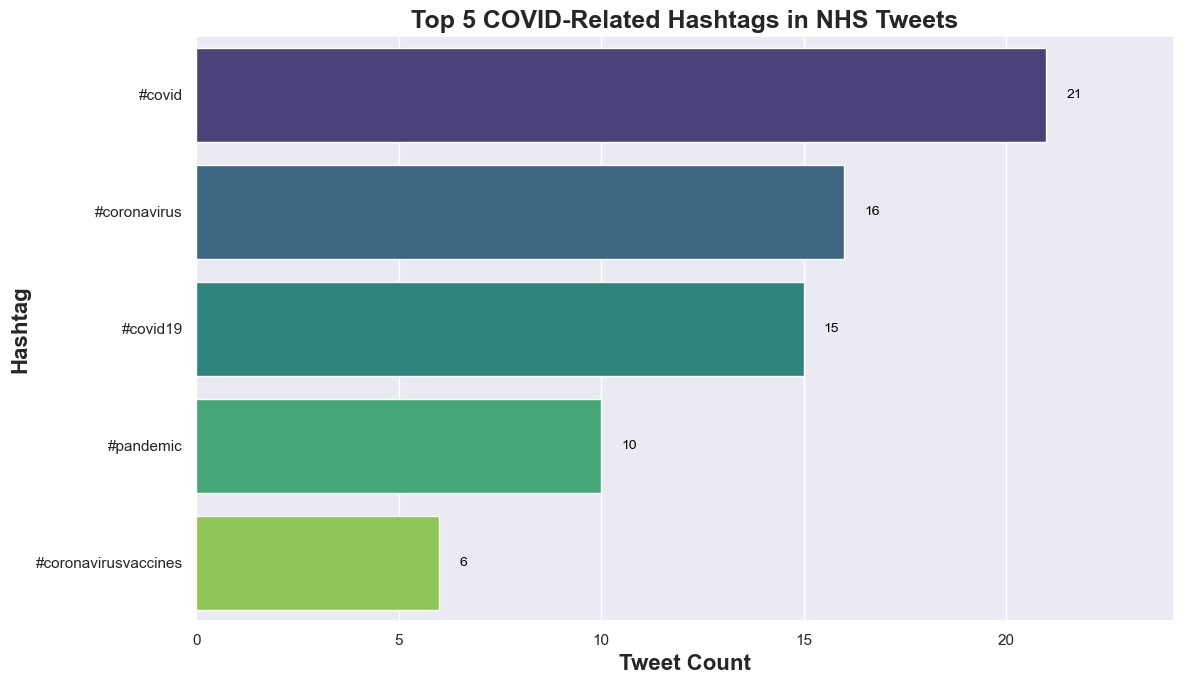

In [135]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select top 10 (or another number) for clarity
top_n = 5
top_covid = covid_count.head(top_n)  # DataFrame with columns 'hashtag' and 'count'

plt.figure(figsize=(12, 7))
ax = sns.barplot(
    y='hashtag', x='count', data=top_covid, palette='viridis', errorbar=None
)

plt.title(f'Top {top_n} COVID-Related Hashtags in NHS Tweets', fontsize=18, fontweight = 'bold')
plt.xlabel('Tweet Count', fontsize = 16, fontweight = 'bold')
plt.ylabel('Hashtag', fontsize = 16, fontweight = 'bold')
plt.yticks(fontsize=11)

# Add count labels
for p in ax.patches:
    ax.text(
        p.get_width() + 0.5,                             # x position: end of bar plus a gap
        p.get_y() + p.get_height() / 2,                  # y position: center of bar
        int(p.get_width()),                              # Text: the count
        va='center', ha='left', fontsize=10, color='black'
    )

plt.xlim(0, top_covid['count'].max() * 1.15)
plt.tight_layout()

plt.savefig('CovidSentimentAnalysisTwitterData.png', dpi = 300, bbox_inches = 'tight')
plt.show()


# Twitter Data Scraping (Sentiment Analysis)

**Insights Gathered:**
Through the practice of sentiment analysis, it was found that telehealth consultations and platforms saw a rise in popularity during the COVID-19 pandemic. Additionally, there were no tweets or comments regarding staffing issues or incompetence in the NHS system.
There were a few tweets regarding bringing awareness to the importance of cybersecurity and growing technology. 

# Assignment activity 6

### Make recommendations to the NHS. 

In [136]:
# Prepare your workstation.
# Use the ar_unique DataFrame (appoint_regionals.csv without the duplicates)
# View the first 5 rows of the DataFrame.

ar_unique.head(5)

,icb_ons_code,appointment_month,appointment_status,hcp_type,appointment_mode,time_between_book_and_appointment,count_of_appointments
0,E54000034,2020-01,Attended,GP,Face-to-Face,1 Day,8107
1,E54000034,2020-01,Attended,GP,Face-to-Face,15 to 21 Days,6791
2,E54000034,2020-01,Attended,GP,Face-to-Face,2 to 7 Days,20686
3,E54000034,2020-01,Attended,GP,Face-to-Face,22 to 28 Days,4268
4,E54000034,2020-01,Attended,GP,Face-to-Face,8 to 14 Days,11971


In [137]:
# Print the min and max dates.
ar_min_date = ar_unique['appointment_month'].agg('min')

ar_max_date = ar_unique['appointment_month'].agg('max')

print(f"The earliest appointment date is: {ar_min_date}")
print(f"The latest appointment date is: {ar_max_date}")

The earliest appointment date is: 2020-01
The latest appointment date is: 2022-06


In [138]:
# Filter the data set to only look at data from 2021-08 onwards.
filtered_ar = ar_unique[ar_unique['appointment_month'] >= '2021-08']

filtered_ar.head()

,icb_ons_code,appointment_month,appointment_status,hcp_type,appointment_mode,time_between_book_and_appointment,count_of_appointments
3652,E54000034,2021-08,Attended,GP,Face-to-Face,1 Day,6553
3653,E54000034,2021-08,Attended,GP,Face-to-Face,15 to 21 Days,2390
3654,E54000034,2021-08,Attended,GP,Face-to-Face,2 to 7 Days,10547
3655,E54000034,2021-08,Attended,GP,Face-to-Face,22 to 28 Days,937
3656,E54000034,2021-08,Attended,GP,Face-to-Face,8 to 14 Days,4961


**Question 1:** Should the NHS start looking at increasing staff levels? 

In [139]:
# Create an aggregated data set to review the different features.
columns = ['appointment_month', 'hcp_type', 'appointment_status', 'appointment_mode',
            'time_between_book_and_appointment', 'count_of_appointments']

ar_agg = filtered_ar[columns] 

ar_agg = ar_agg.groupby(['appointment_month', 'hcp_type', 'appointment_status', 'appointment_mode', 
                         'time_between_book_and_appointment'])['count_of_appointments'].sum().reset_index()

# View the DataFrame.
ar_agg.head()

,appointment_month,hcp_type,appointment_status,appointment_mode,time_between_book_and_appointment,count_of_appointments
0,2021-08,GP,Attended,Face-to-Face,1 Day,507835
1,2021-08,GP,Attended,Face-to-Face,15 to 21 Days,194726
2,2021-08,GP,Attended,Face-to-Face,2 to 7 Days,959486
3,2021-08,GP,Attended,Face-to-Face,22 to 28 Days,102111
4,2021-08,GP,Attended,Face-to-Face,8 to 14 Days,398772


In [140]:
# Determine the total number of appointments per month.
ar_monthly = filtered_ar.groupby('appointment_month')['count_of_appointments'].sum().reset_index()
ar_monthly.rename(columns={'count_of_appointments': 'monthly_appointments'}, inplace=True)

# Add a new column to indicate the average utilisation of services.
# NHS has a daily appointment value of 1.2 million for planning maximum capacity.
# Monthly aggregate / 30 to get to a daily value.

ar_monthly['utilisation'] = (ar_monthly['monthly_appointments'] / (1_200_000 * 30)).round(1)


# View the DataFrame.
ar_monthly.head()


,appointment_month,monthly_appointments,utilisation
0,2021-08,23843177,0.7
1,2021-09,28514685,0.8
2,2021-10,30296850,0.8
3,2021-11,30395923,0.8
4,2021-12,25132174,0.7


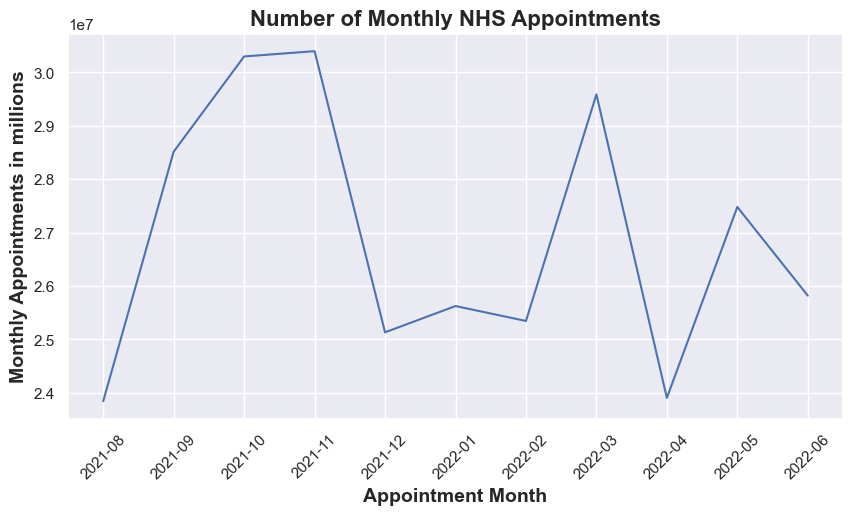

In [141]:
# Plot sum of count of monthly visits.
# Convert the appointment_month to string data type for ease of visualisation.
ar_agg['appointment_month'] = ar_agg['appointment_month'].astype(str)
ar_monthly['appointment_month'] = ar_monthly['appointment_month'].astype(str)

# Create a lineplot with Seaborn.
import seaborn as sns
import matplotlib.pyplot as plt

# Monthly visits plot
plt.figure(figsize=(10,5))
sns.lineplot(data=ar_monthly, x='appointment_month', y='monthly_appointments')
plt.title("Number of Monthly NHS Appointments", fontsize = 16, fontweight = 'bold')
plt.ylabel('Monthly Appointments in millions', fontsize = 14, fontweight = 'bold')
plt.xlabel('Appointment Month', fontsize = 14, fontweight = 'bold')
plt.xticks(rotation=45)

plt.savefig('MonthlyVisits.png', dpi = 300, bbox_inches = 'tight')
plt.show()


**Observations:**
- The NHS has consistently handled between 24 million and just over 30 million appointments each month from August 2021 to June 2022.
- Noticeable increase in monthly appointments from August to November 2021: could indicate the aftermath of the second wave of the COVID-19 pandemic.
- November 2021 had the highest volume of appointments.
- Sharp decline in appointments from November 2021 to December 2021: could indicate seasonal fluctuation (holiday season).
- After each dip (December 2021 - April 2022), there is a marked rebound in the following months, suggesting that the NHS can recover service volume after short-term drops.

**Insights Gathered:**
- The NHS is consistently meeting high appointment demand with only short, predictable dips. 
- No evidence of long-term under-performance can be seen.
- The NHS has a benchmark of about 1.2 million appointments per day. In a 31-day month, 1.2 million * 31 = 37200000 appointments. In a 30-day month, 1.2 million * 30 = 36000000 appointments. According to the plot, the NHS is well-staffed to deal with these volumes of appointments.

**Recommendations:**
- Regular monitoring, staff flexibility, and proactive management of seasonal variations will further strengthen system resilience and care quality.
- There is no need for an increase in the NHS's capacity. 

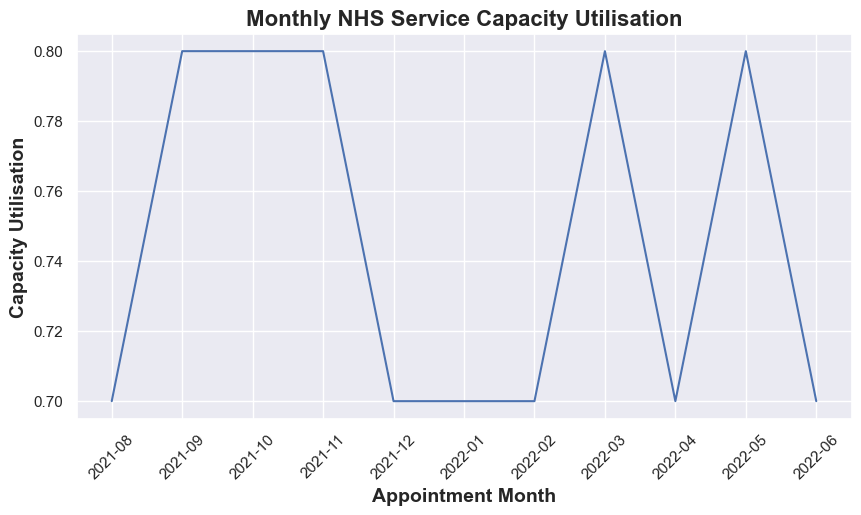

In [142]:
# Import necessary packages.
import seaborn as sns
import matplotlib.pyplot as plt

# Plot monthly capacity utilisation.
plt.figure(figsize=(10,5))
sns.lineplot(data=ar_monthly, x='appointment_month', y='utilisation')
plt.title("Monthly NHS Service Capacity Utilisation", fontsize = 16, fontweight = 'bold')
plt.ylabel('Capacity Utilisation', fontsize = 14, fontweight = 'bold')
plt.xlabel('Appointment Month', fontsize = 14, fontweight = 'bold')
plt.xticks(rotation=45)

# View lineplot.
plt.savefig('CapacityUtilisation.png', dpi = 300, bbox_inches = 'tight')
plt.show()


**Answer:  No, the staffing capacity is sufficient, and there is no need to increase the staffing levels.
From the above table, it can be seen that the capacity utilisation never exceeds 1 (100%), suggesting that the NHS's service capacity utilisation values are stable and relatively high (around 0.75-0.8 or 75-80%).
The NHS is matching its staffing and capacity to patient demand—neither underutilising valuable resources nor overstretched—thus indicating an appropriate and sufficient level of staffing.**

**Question 2:** How do the healthcare professional types differ over time?

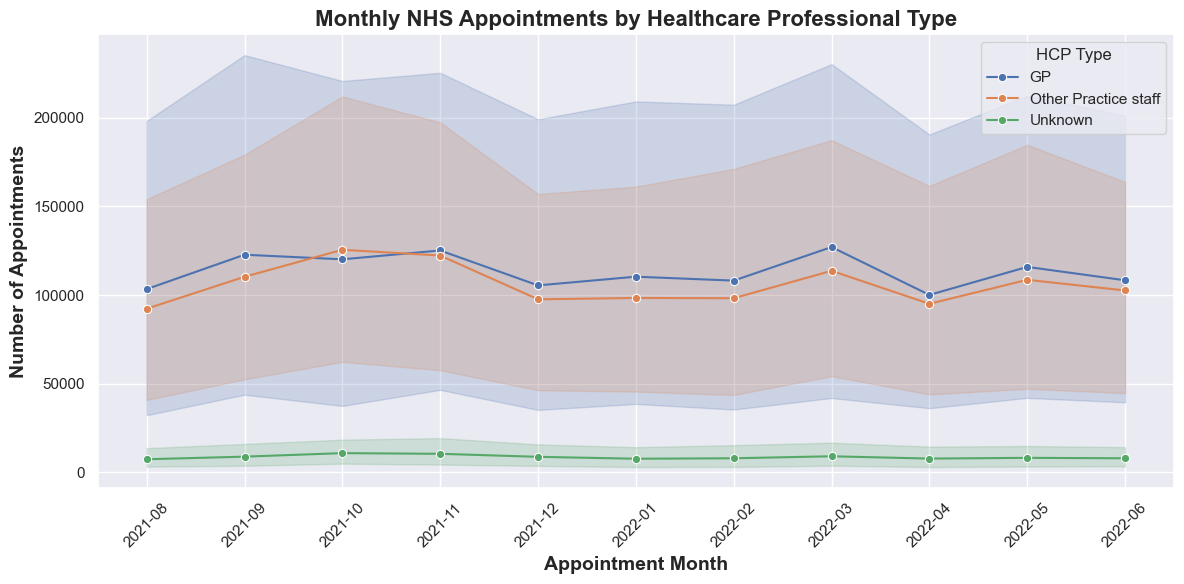

In [143]:
# Create a line plot to answer the question.
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=ar_agg,
    x='appointment_month',
    y='count_of_appointments',
    hue='hcp_type',
    marker='o'
)

plt.title("Monthly NHS Appointments by Healthcare Professional Type", fontsize = 16, fontweight = 'bold')
plt.xlabel("Appointment Month", fontsize = 14, fontweight = 'bold')
plt.ylabel("Number of Appointments", fontsize = 14, fontweight = 'bold')
plt.xticks(rotation=45)
plt.legend(title='HCP Type', loc = 'upper right')
plt.tight_layout()

plt.savefig('Appointments_by_HCP.png', dpi = 300, bbox_inches = 'tight')
plt.show()


1. General Practitioner (GP) Line: GPs typically manage the largest number of appointments, acting as the NHS’s primary contact point. This line leads every month by a wide margin, it highlights their central role and ongoing high workload.
2. Nurse/Specialist Lines Fluctuate or Follow Patterns: If the lines for Nurses or Specialists mirror overall trends but at a lower level, it shows these roles are important but serve more targeted needs.
3. Sudden Increases or Decreases: Noticeable surges could indicate COVID waves; drops could align with winter holidays or staff shortages.

**Question 3:** Are there significant changes in whether or not visits are attended?

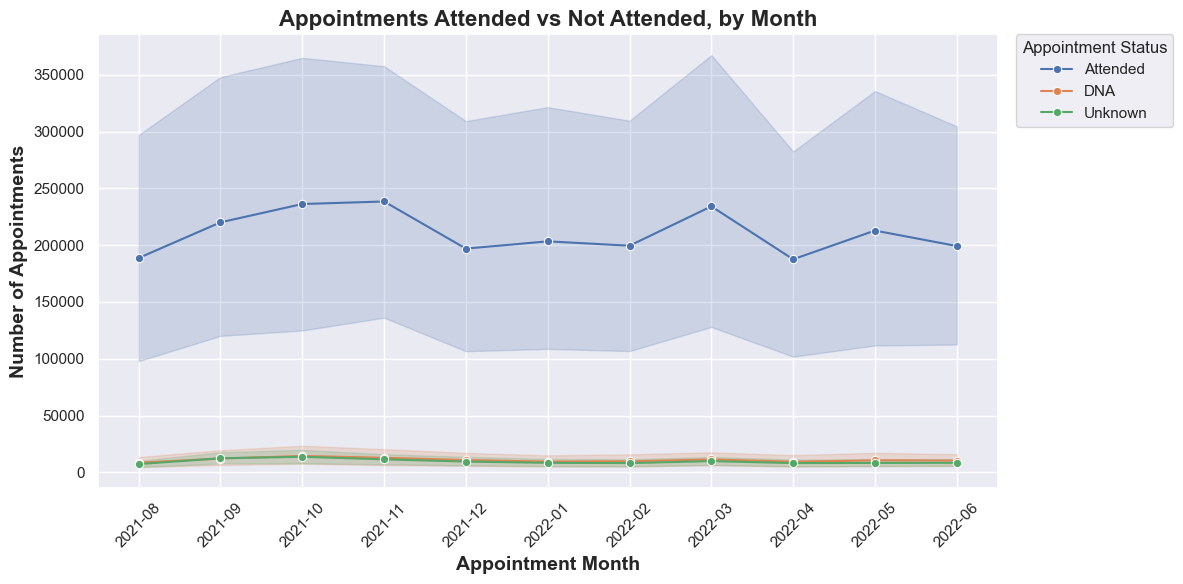

In [144]:
# Create a line plot to answer the question.
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6), constrained_layout=True)
sns.set_style('darkgrid')

sns.lineplot(
    data=ar_agg,                             # DataFrame with filtered and grouped data
    x='appointment_month',                   # X-axis: month of appointment
    y='count_of_appointments',               # Y-axis: number of appointments
    hue='appointment_status',                # Different lines for Attended/DNA/Unknown
    marker='o'
)
plt.title("Appointments Attended vs Not Attended, by Month", fontsize = 16, fontweight = 'bold')
plt.xlabel("Appointment Month", fontsize = 14, fontweight = 'bold')
plt.ylabel("Number of Appointments", fontsize = 14, fontweight = 'bold')
plt.xticks(rotation=45)
plt.legend(title='Appointment Status', loc = 'best', bbox_to_anchor=(1.02, 1), borderaxespad=0)
plt.tight_layout()

plt.savefig('AppointmentAttended_vs_Not.png', dpi = 300, bbox_inches = 'tight')
plt.show()


1. There is a decrease in attended appointments from November 2021 to December 2021. This could be because of multiple factors involved:
   - Holiday Season Impact (Christmas, New Year).
   - Reduced availability of Staff and Services (annual leave period).
   - Patient behaviour: patients tend to postpone follow-up appointments intentionally until after the holiday period.
   - Weather-Related Barriers: December weather is very cold and icy in the UK, which could make travel difficult, increasing the likelihood of missed appointments.

     
2. There is a steep increase in the number of attended appointments from February 2022 to March 2022. This could be because of the following factors:
   - Increase in total appointments: There was an overall increase in the number of GP appointments during the spring of 2022 when compared to pre-pandemic levels.
   - Increase in appointments with other practice staff.
   - Telephonic and Video/Online consultations remain significant post-pandemic. They made a considerable portion of the number of attended appointments.

**Question 4:** Are there changes in terms of appointment type and the busiest months?

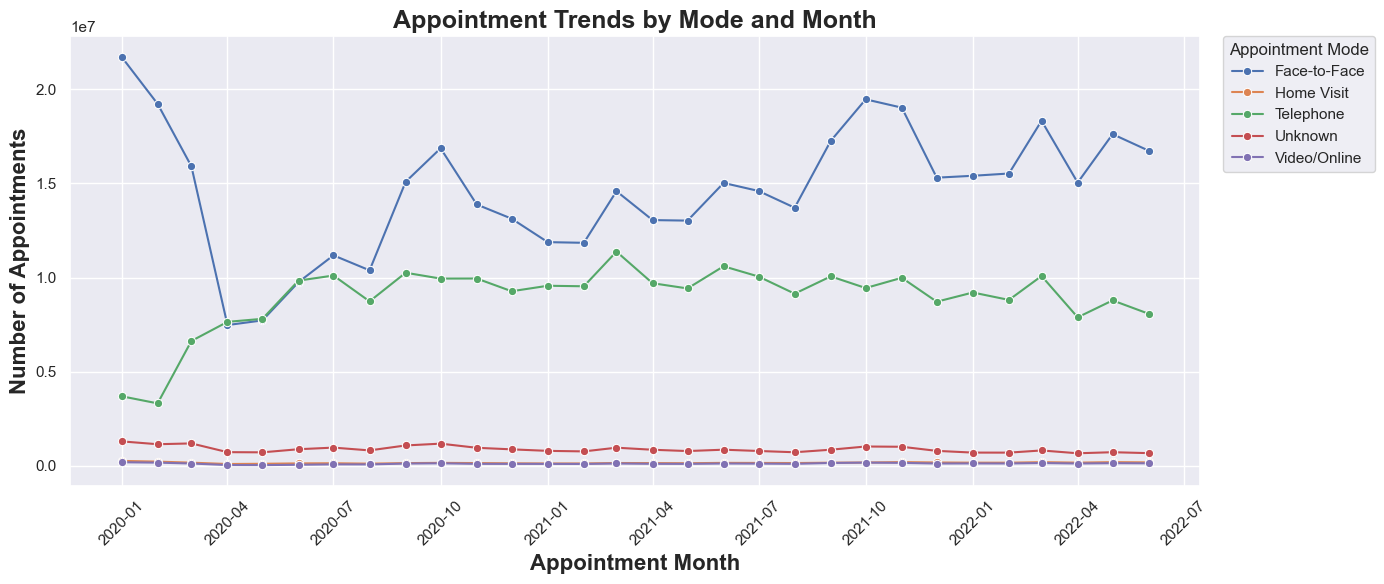

In [145]:
# Create a line plot to answer the question.
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Prepare appointment_month as datetime for sorting
ar_unique['appointment_month'] = pd.to_datetime(ar_unique['appointment_month'])

# Aggregate appointments by month and mode
monthly_mode_counts = (
    ar_unique.groupby(['appointment_month', 'appointment_mode'])['count_of_appointments']
    .sum()
    .reset_index()
)

# View Plot
plt.figure(figsize=(14,6), constrained_layout=True)
sns.lineplot(
    data=monthly_mode_counts,
    x='appointment_month',
    y='count_of_appointments',
    hue='appointment_mode',
    marker='o'
)

plt.legend(title='Appointment Mode', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.title('Appointment Trends by Mode and Month', fontsize = 18, fontweight = 'bold')
plt.xlabel('Appointment Month', fontsize = 16, fontweight = 'bold')
plt.ylabel('Number of Appointments', fontsize = 16, fontweight = 'bold')
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('TrendsbymodeandMonth.png', dpi = 300, bbox_inches = 'tight')
plt.show()


**Observations:**
1. Steep decline in the number of face-to-face appointments from Jan 2020 - March 2020 due to the COVID pandemic
2. Steady incline in telephonic consults from Feb 2020 to July 2020
3. There is a noticeable fluctuation in the Face-to-Face appointments, whereas the Telephone consultations have maintained their popularity

**Question 5:** Are there any trends in time between booking and appointment?

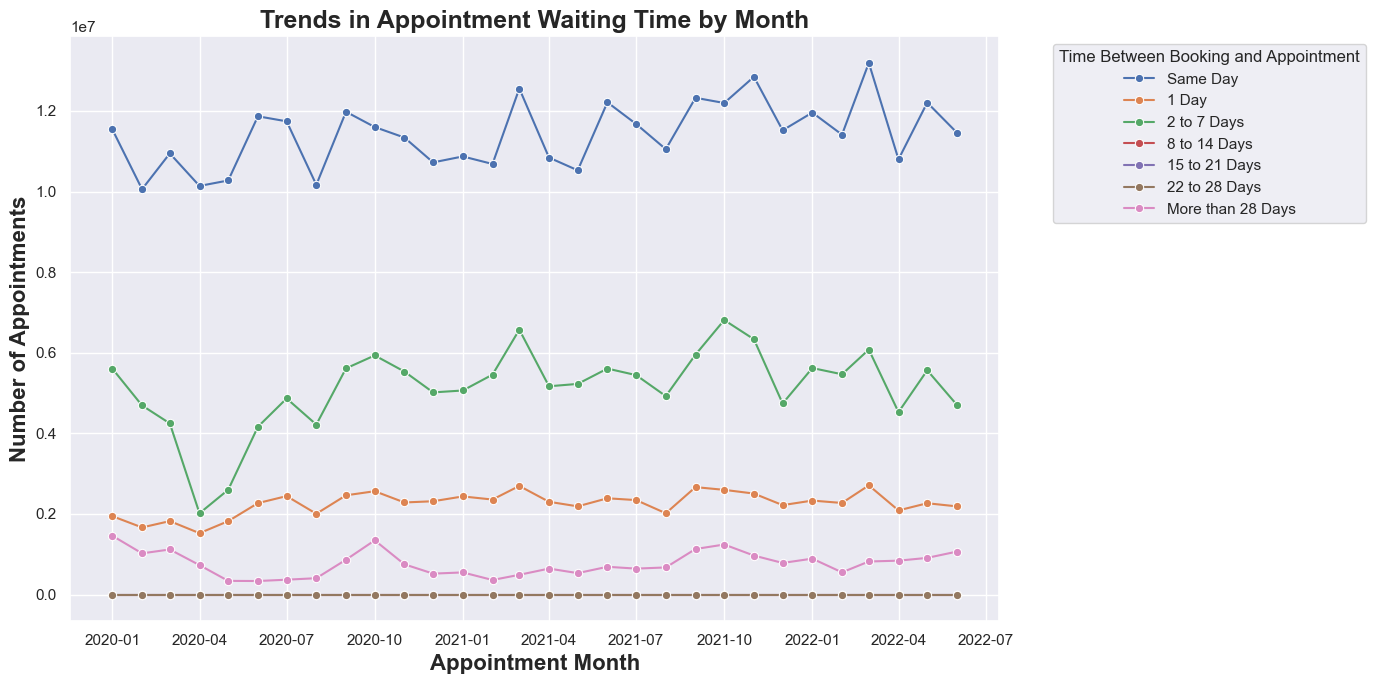

In [146]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert appointment_month to datetime for ordering
ar_unique['appointment_month'] = pd.to_datetime(ar_unique['appointment_month'])

# Sort the DataFrame for plot
ar_unique = ar_unique.sort_values('appointment_month')

# Custom order for time bins
time_order = [
    'Same Day', '1 Day', '2 to 7 Days', '8 to 14 Days', '15 to 21 Days',
    '22 to 28 Days', 'More than 28 Days'
]
ar_unique['time_between_book_and_appointment'] = pd.Categorical(
    ar_unique['time_between_book_and_appointment'], 
    categories=time_order, 
    ordered=True
)

# Aggregate total appointments by month and time bin
trend = ar_unique.groupby(['appointment_month', 'time_between_book_and_appointment'])['count_of_appointments'].sum().reset_index()

# Plot
plt.figure(figsize=(14,7))
sns.lineplot(
    data=trend, 
    x='appointment_month',
    y='count_of_appointments', 
    hue='time_between_book_and_appointment', 
    marker='o'
)

plt.title('Trends in Appointment Waiting Time by Month', fontsize = 18, fontweight = 'bold')
plt.xlabel('Appointment Month', fontsize = 16, fontweight = 'bold')
plt.ylabel('Number of Appointments',fontsize = 16, fontweight = 'bold')
plt.legend(title='Time Between Booking and Appointment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.savefig('Appointment Wait Time by Month.png', dpi = 300, bbox_inches = 'tight')
plt.show()

**Observations:**
1. High number of same-day appointments.
2. A very low number of appointments if the time interval between the booking and appointment is large.

**Question 6:** How do the various service settings compare?

In [147]:
# Let's go back to the national category DataFrame you created in an earlier assignment activity.
nc.head()

,appointment_date,icb_ons_code,sub_icb_location_name,service_setting,context_type,national_category,count_of_appointments,appointment_month,month,Day Index,Day Name,year_week,day_type
0,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,Primary Care Network,Care Related Encounter,Patient contact during Care Home Round,3,2021-08,2021-08,0,Monday,2021-31,weekday
1,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,Other,Care Related Encounter,Planned Clinics,7,2021-08,2021-08,0,Monday,2021-31,weekday
2,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Home Visit,79,2021-08,2021-08,0,Monday,2021-31,weekday
3,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,General Consultation Acute,725,2021-08,2021-08,0,Monday,2021-31,weekday
4,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Structured Medication Review,2,2021-08,2021-08,0,Monday,2021-31,weekday


In [148]:
# Create a new DataFrame consisting of the month of appointment and the number of appointments.
nc_grouped = (
    nc.groupby(['appointment_month', 'service_setting'])['count_of_appointments']
    .sum()
    .reset_index()
)

# View the DataFrame.
nc_grouped.head()

,appointment_month,service_setting,count_of_appointments
0,2021-08,Extended Access Provision,160927
1,2021-08,General Practice,21575852
2,2021-08,Other,449101
3,2021-08,Primary Care Network,432448
4,2021-08,Unmapped,1233843


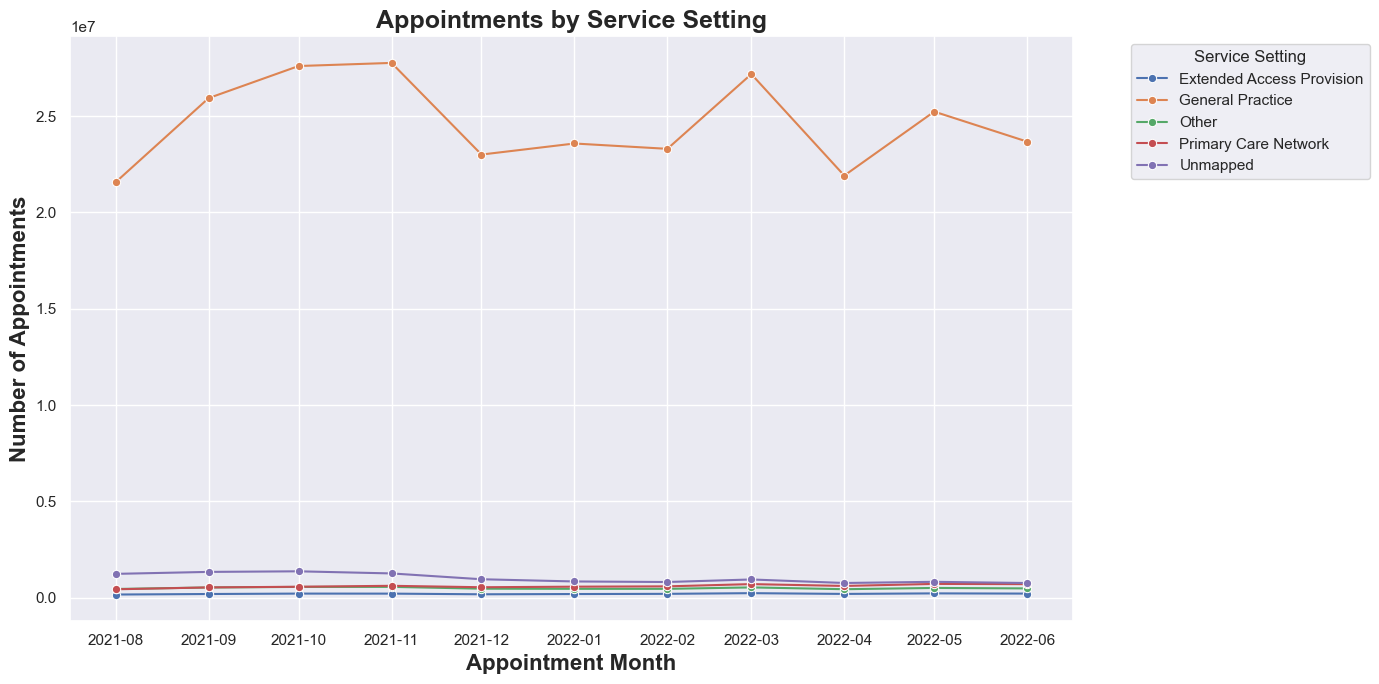

In [149]:
# Creating a lineplot in Seaborn based on the new DataFrame to indicate the service settings for the number of appointments.
nc_grouped['appointment_month'] = pd.to_datetime(nc_grouped['appointment_month'])
nc_grouped.sort_values('appointment_month', inplace=True)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,7))
sns.lineplot(
    data=nc_grouped,
    x='appointment_month',
    y='count_of_appointments',
    hue='service_setting',
    marker='o'
)
plt.title('Appointments by Service Setting', fontsize = 18, fontweight = 'bold')
plt.xlabel('Appointment Month', fontsize = 16, fontweight = 'bold')
plt.ylabel('Number of Appointments', fontsize = 16, fontweight = 'bold')
plt.legend(title='Service Setting', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

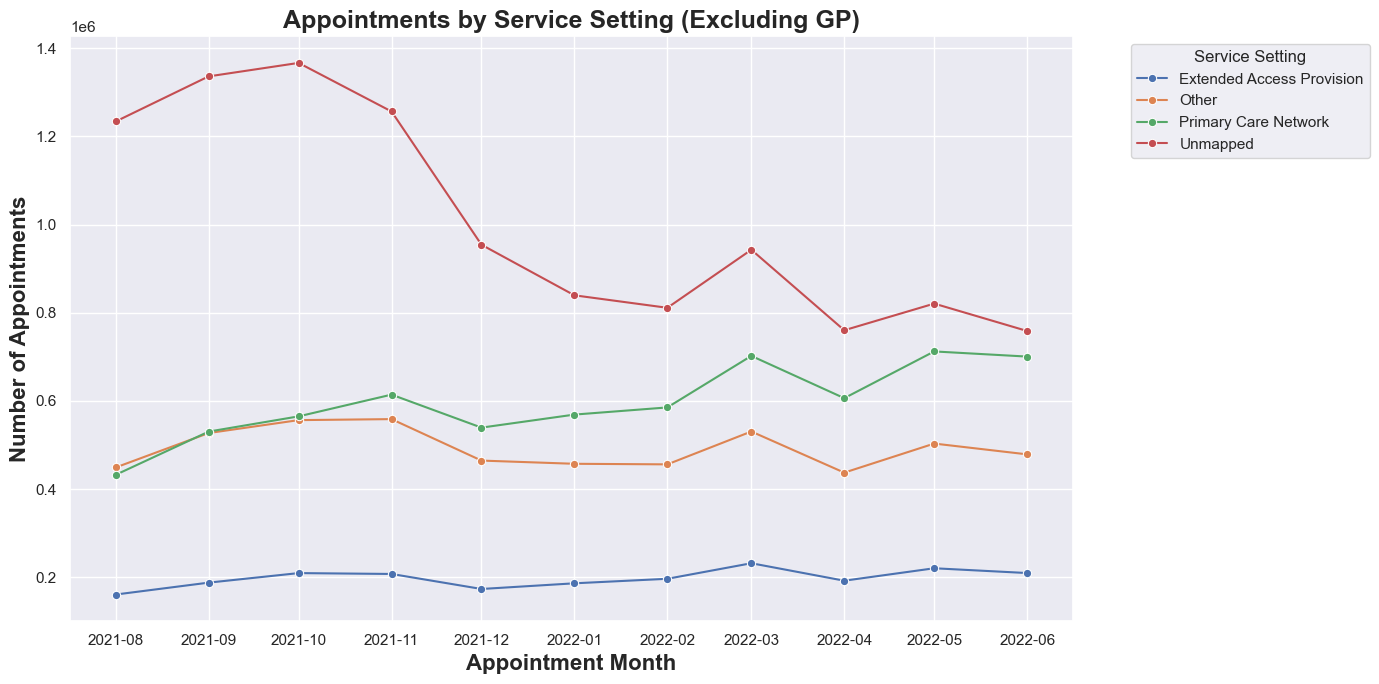

In [150]:
# Creating a lineplot in Seaborn where you concentrate on all the service settings, excluding GP visits.
exclude_gp = nc_grouped[nc_grouped['service_setting'] != 'General Practice']

plt.figure(figsize=(14,7))
sns.lineplot(
    data=exclude_gp,
    x='appointment_month',
    y='count_of_appointments',
    hue='service_setting',
    marker='o'
)
plt.title('Appointments by Service Setting (Excluding GP)', fontsize = 18, fontweight = 'bold')
plt.xlabel('Appointment Month', fontsize = 16, fontweight = 'bold')
plt.ylabel('Number of Appointments', fontsize = 16, fontweight = 'bold')
plt.legend(title='Service Setting', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.savefig('Apts excluding GP.png', dpi = 300, bbox_inches = 'tight')
plt.show()


**Observations:**
1. GPs have the highest appointments.
2. Primary Care and Other service settings saw a notable growth in March 2022.
3. Steep decline in Unmapped appointments post pandemic, suggesting that the disruption was temporary due to COVID-19 demands.

### Provide a summary of your findings and recommendations based on the analysis.

# Summary of Overall Findings

The diagnostic analysis of NHS appointment data reveals that the healthcare system is effectively managing a high monthly workload, consistently handling between 24 and 30 million appointments across 7 regions and 42 ICBs, with general practice and face-to-face interactions remaining dominant. Seasonal trends are evident, with appointment peaks around November and dips during major holidays, but the system consistently rebounds, suggesting strong operational resilience. Missed appointment rates are low overall (4.2%) and are most common for long-lead time and face-to-face bookings, whereas same-day and telephone consultations have the highest attendance. The COVID-19 period brought a surge in telephone consultations that, while declining post-pandemic, remain above pre-pandemic levels, indicating a lasting shift towards hybrid care. Public sentiment analysis further underscores the significance of telehealth and technology in patient perceptions of the NHS. Importantly, no evidence suggests the need for increased staffing, as current capacity utilisation consistently remains below critical thresholds, demonstrating that existing resources are well-matched to patient demand.


# Key Insights (Concise)
1. The NHS appointment system is robust and resilient, with no signs of overstretched or wasted service capacity.
2. Hybrid care delivery is now an enduring norm—plan for flexibility, not a “return to old normal.” -
3. Reducing booking lead times, investing in patient reminders, and continuous data quality improvements are immediate priorities with a high return on investment.
4. No need for immediate staffing increases, but readiness for seasonal surges and ongoing agile workforce management remains critical.
5. Ongoing monitoring and regional learning will help continuously optimise NHS performance and patient satisfaction.

# Key Insights (Detailed)
1. The NHS consistently handles high volumes of appointments (24–30 million monthly), with General Practice accounting for the majority of visits and face-to-face consultations remaining the most common mode.
2. Appointment activity shows strong seasonal and monthly patterns, peaking in November and after major holidays, with predictable dips during festive periods such as December; the system reliably rebounds after these declines.
3. Missed appointments (DNA) represent a small share (4.2%) of total bookings, but are more likely with longer booking lead times and for face-to-face and home visit modes. Same-day and telephone appointments have the highest attendance rates.
4. The COVID-19 pandemic triggered a permanent rise in remote consultations (telephone and video), which now make up a stable, significant portion of all appointments, signalling a lasting shift toward hybrid care.
5. Regional analysis highlights that areas like North East and North Cumbria consistently have the highest appointment numbers and distinct adoption patterns for appointment modes.
6. Weekly and daily trends show appointment activity is heavily concentrated on weekdays, especially Tuesdays and Wednesdays, with little activity on weekends.
7. Despite this high demand, NHS staffing levels and resource allocation have proven sufficient, as capacity utilisation has remained well below maximum thresholds throughout the period studied.
8. Twitter sentiment analysis indicates the public is focused on issues like telehealth adoption and healthcare technology, with limited concern about staffing shortages or care quality, reinforcing the NHS’s reputation for resilience and adaptability.

# Recommendations
1. **Maintain and Enhance Hybrid Care Delivery:** Continue supporting a balanced mix of face-to-face and remote (telephone and video) consultations, as both are now integral to patient care and system flexibility. Invest in digital infrastructure and training to ensure high-quality delivery across all modes.
2. **Reduce Missed Appointments (DNA) Through Proactive Strategies:** Implement or expand automated reminder systems (via SMS, email, or calls), especially for longer lead-time and face-to-face bookings. Encourage patient rescheduling and cancellation when needed, and provide streamlined options for doing so.
3. **Optimise Appointment Scheduling:** Shorten booking lead times where possible to reduce DNA rates, and prioritise flexible scheduling that allows for same-day and quick-access appointments, especially in high-demand regions or populations with historically higher non-attendance.
4. **Prepare for Seasonal Peaks and Demand Fluctuations:** Adjust staffing and service planning in anticipation of recurring appointment surges in months like November and during post-holiday rebounds. Implement flexible staffing models to adapt to these forecastable variations.
5. **Enhance Data Quality & Monitoring:** Reduce “unknown” or unmapped entries through regular data audits and frontline staff training in data entry best practices. Continuously refine classification processes to ensure accurate service setting and outcome mapping.
6. **Learn from High-Performing Regions:** Analyse regions such as North East and North Cumbria that consistently outperform in appointment efficiency or adoption of remote modalities to share best practices NHS-wide.
7. **Sustain Efficient Resource Allocation:** Maintain current staffing levels and resource distribution, as capacity utilisation data indicates that the system is well-matched to demand. Regularly monitor utilisation metrics to quickly identify and address any emerging bottlenecks.
8. **Promote Digital Inclusion:** Ensure that all patient groups, including the digitally excluded, can access both remote and in-person services. Continue supporting digital inclusion initiatives, making telehealth options available but never mandatory.
9. **Engage with Public Feedback:** Regularly review patient and public sentiment—such as social media analytics—to identify shifting needs and emerging concerns, and adapt services accordingly.
